In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
from torch.utils.data import random_split
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.functional as TF
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
import torch.nn.functional as F

# Model

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
# convert images to tensor and normalize
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# Load dataset
full_train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# 5% from each class
def sample_5_percent(dataset):
    class_indices = {i: [] for i in range(10)}

    for idx, (_, label) in enumerate(dataset):
        class_indices[label].append(idx)

    sampled_indices = []
    for label in range(10):
        sampled_count = int(len(class_indices[label]) * 0.05)
        sampled_indices += np.random.choice(class_indices[label], sampled_count, replace=False).tolist()

    return Subset(dataset, sampled_indices)

# 5% data from each class
train_dataset = sample_5_percent(full_train_dataset)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [ ]:
# Splitting
train_size = int(0.7 * len(train_dataset))
val_size = int(0.15 * len(train_dataset))
test_size = len(train_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(train_dataset, [train_size, val_size, test_size])

# DataLoader for each split
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.cnn_layer_1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=2)
        self.cnn_layer_2 = nn.Conv2d(in_channels=16, out_channels=32,kernel_size=5, stride=1, padding=2)

        self.flatten = nn.Flatten()
        self.maxpool = nn.MaxPool2d(2,2)

        self.linear_layer_1 = nn.Linear(32*7*7, 512)
        self.linear_layer_2 = nn.Linear(512, 128)
        self.linear_layer_3 = nn.Linear(128, 10)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(.2)

        # self.flatten = nn.Flatten()

    def forward(self, x):
        x = self.cnn_layer_1(x)
        x = self.dropout(x)
        x = self.relu(x)
        x = self.maxpool(x)

        #print(x.shape)

        x = self.cnn_layer_2(x)
        x = self.dropout(x)
        x = self.relu(x)
        x = self.maxpool(x)

        #print(x.shape)

        x = self.flatten(x)
        #print(x.shape)

        x = self.linear_layer_1(x)
        x = self.dropout(x)
        x = self.relu(x)

        x = self.linear_layer_2(x)
        x = self.dropout(x)
        x = self.relu(x)

        x = self.linear_layer_3(x)
        #logits = self.sigmoid(x)
        return x

In [ ]:
model = NeuralNetwork()
#print(model.to(device))

In [ ]:
from torchsummary import summary
summary(model,(1, 28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 28, 28]             416
           Dropout-2           [-1, 16, 28, 28]               0
              ReLU-3           [-1, 16, 28, 28]               0
         MaxPool2d-4           [-1, 16, 14, 14]               0
            Conv2d-5           [-1, 32, 14, 14]          12,832
           Dropout-6           [-1, 32, 14, 14]               0
              ReLU-7           [-1, 32, 14, 14]               0
         MaxPool2d-8             [-1, 32, 7, 7]               0
           Flatten-9                 [-1, 1568]               0
           Linear-10                  [-1, 512]         803,328
          Dropout-11                  [-1, 512]               0
             ReLU-12                  [-1, 512]               0
           Linear-13                  [-1, 128]          65,664
          Dropout-14                  [

In [ ]:
def train(model, train_loader, val_loader, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        print(f"Epoch {epoch + 1}, Loss: {running_loss / len(train_loader):.3f}")

        # Validation phase
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        print(f"Validation Accuracy: {100 * correct / total:.3f}%")

# Train the model
train(model, train_loader, val_loader)

# Save the model
torch.save(model.state_dict(), 'mnist_cnn.pth')

Epoch 1, Loss: 0.075
Validation Accuracy: 94.655%
Epoch 2, Loss: 0.040
Validation Accuracy: 96.214%
Epoch 3, Loss: 0.027
Validation Accuracy: 95.991%
Epoch 4, Loss: 0.025
Validation Accuracy: 94.655%
Epoch 5, Loss: 0.024
Validation Accuracy: 94.878%


In [ ]:
# Load the saved model
loaded_model = NeuralNetwork().to(device)
loaded_model.load_state_dict(torch.load('mnist_cnn.pth'))
loaded_model.eval()

# Testing on regular test set
def test(model, test_loader):
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Test Accuracy: {100 * correct / total:.3f}%")

test(loaded_model, test_loader)

Test Accuracy: 96.222%


# Rotation

In [ ]:
rotation_angles = list(range(0, 181, 5))

# Store metrics
rotation_metrics = {
    'overall_accuracy': [],
    'class_accuracy': {i: [] for i in range(10)},
    'precision': {i: [] for i in range(10)},
    'recall': {i: [] for i in range(10)},
    'f1': {i: [] for i in range(10)},
    'auc': {i: [] for i in range(10)}
}

# Rotate and evaluate
for angle in rotation_angles:
    rotated_images = []
    rotated_labels = []

    for image, label in test_dataset:
        img = TF.rotate(image, angle)
        rotated_images.append(img)
        rotated_labels.append(label)

    rotated_loader = DataLoader(list(zip(rotated_images, rotated_labels)), batch_size=64)

    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for images, labels in rotated_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = loaded_model(images)

            _, preds = torch.max(outputs, 1)
            probs = torch.nn.functional.softmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    all_probs = np.array(all_probs)

    # Overall accuracy
    acc = accuracy_score(all_targets, all_preds)
    rotation_metrics['overall_accuracy'].append(acc)
    print(f"Rotation {angle}° -> Accuracy: {acc:.4f}")

    # Class-wise metrics
    for i in range(10):
        class_idx = np.where(all_targets == i)[0]
        if len(class_idx) > 0:
            correct = np.sum(all_preds[class_idx] == i)
            class_accuracy = correct / len(class_idx)
            rotation_metrics['class_accuracy'][i].append(class_accuracy)

            binary_true = (all_targets == i).astype(int)
            binary_pred = (all_preds == i).astype(int)

            rotation_metrics['precision'][i].append(precision_score(binary_true, binary_pred, zero_division=0))
            rotation_metrics['recall'][i].append(recall_score(binary_true, binary_pred, zero_division=0))
            rotation_metrics['f1'][i].append(f1_score(binary_true, binary_pred, zero_division=0))

            try:
                rotation_metrics['auc'][i].append(roc_auc_score(binary_true, all_probs[:, i]))
            except ValueError:
                rotation_metrics['auc'][i].append(float('nan'))  # Ensure consistent length

Rotation 0° -> Accuracy: 0.9622
Rotation 5° -> Accuracy: 0.9489
Rotation 10° -> Accuracy: 0.9444
Rotation 15° -> Accuracy: 0.9267
Rotation 20° -> Accuracy: 0.8844
Rotation 25° -> Accuracy: 0.8222
Rotation 30° -> Accuracy: 0.7444
Rotation 35° -> Accuracy: 0.6511
Rotation 40° -> Accuracy: 0.5778
Rotation 45° -> Accuracy: 0.4956
Rotation 50° -> Accuracy: 0.4156
Rotation 55° -> Accuracy: 0.3311
Rotation 60° -> Accuracy: 0.2689
Rotation 65° -> Accuracy: 0.2289
Rotation 70° -> Accuracy: 0.1978
Rotation 75° -> Accuracy: 0.1689
Rotation 80° -> Accuracy: 0.1556
Rotation 85° -> Accuracy: 0.1356
Rotation 90° -> Accuracy: 0.1222
Rotation 95° -> Accuracy: 0.1244
Rotation 100° -> Accuracy: 0.1178
Rotation 105° -> Accuracy: 0.1200
Rotation 110° -> Accuracy: 0.1067
Rotation 115° -> Accuracy: 0.1178
Rotation 120° -> Accuracy: 0.1133
Rotation 125° -> Accuracy: 0.1244
Rotation 130° -> Accuracy: 0.1400
Rotation 135° -> Accuracy: 0.1867
Rotation 140° -> Accuracy: 0.2089
Rotation 145° -> Accuracy: 0.2444
Ro

In [ ]:
# Compute average metrics per rotation angle
avg_metrics_per_angle = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'auc': []
}

for idx in range(len(rotation_angles)):
    acc = np.mean([rotation_metrics['class_accuracy'][c][idx] for c in range(10)])
    prec = np.mean([rotation_metrics['precision'][c][idx] for c in range(10)])
    rec = np.mean([rotation_metrics['recall'][c][idx] for c in range(10)])
    f1 = np.mean([rotation_metrics['f1'][c][idx] for c in range(10)])
    auc = np.nanmean([rotation_metrics['auc'][c][idx] for c in range(10)])

    avg_metrics_per_angle['accuracy'].append(acc)
    avg_metrics_per_angle['precision'].append(prec)
    avg_metrics_per_angle['recall'].append(rec)
    avg_metrics_per_angle['f1'].append(f1)
    avg_metrics_per_angle['auc'].append(auc)

    print(f"\nRotation {rotation_angles[idx]}° - Avg Metrics:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"  AUC:       {auc:.4f}")



Rotation 0° - Avg Metrics:
  Accuracy:  0.9629
  Precision: 0.9617
  Recall:    0.9629
  F1 Score:  0.9618
  AUC:       0.9990

Rotation 5° - Avg Metrics:
  Accuracy:  0.9495
  Precision: 0.9478
  Recall:    0.9495
  F1 Score:  0.9475
  AUC:       0.9987

Rotation 10° - Avg Metrics:
  Accuracy:  0.9437
  Precision: 0.9448
  Recall:    0.9437
  F1 Score:  0.9430
  AUC:       0.9986

Rotation 15° - Avg Metrics:
  Accuracy:  0.9258
  Precision: 0.9278
  Recall:    0.9258
  F1 Score:  0.9252
  AUC:       0.9964

Rotation 20° - Avg Metrics:
  Accuracy:  0.8840
  Precision: 0.8908
  Recall:    0.8840
  F1 Score:  0.8836
  AUC:       0.9916

Rotation 25° - Avg Metrics:
  Accuracy:  0.8226
  Precision: 0.8322
  Recall:    0.8226
  F1 Score:  0.8217
  AUC:       0.9825

Rotation 30° - Avg Metrics:
  Accuracy:  0.7490
  Precision: 0.7663
  Recall:    0.7490
  F1 Score:  0.7450
  AUC:       0.9668

Rotation 35° - Avg Metrics:
  Accuracy:  0.6556
  Precision: 0.6796
  Recall:    0.6556
  F1 Score

In [ ]:
# Compute and print metrics for each class (0 to 9)
class_metrics = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'auc': []
}

for class_idx in range(10):  # For each class 0 to 9
    acc = np.mean(rotation_metrics['class_accuracy'][class_idx])
    prec = np.mean(rotation_metrics['precision'][class_idx])
    rec = np.mean(rotation_metrics['recall'][class_idx])
    f1 = np.mean(rotation_metrics['f1'][class_idx])
    auc = np.nanmean(rotation_metrics['auc'][class_idx])

    class_metrics['accuracy'].append(acc)
    class_metrics['precision'].append(prec)
    class_metrics['recall'].append(rec)
    class_metrics['f1'].append(f1)
    class_metrics['auc'].append(auc)

    print(f"\nClass {class_idx} - Metrics:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"  AUC:       {auc:.4f}")



Class 0 - Metrics:
  Accuracy:  0.7175
  Precision: 0.6252
  Recall:    0.7175
  F1 Score:  0.6607
  AUC:       0.9288

Class 1 - Metrics:
  Accuracy:  0.4068
  Precision: 0.6637
  Recall:    0.4068
  F1 Score:  0.4624
  AUC:       0.8781

Class 2 - Metrics:
  Accuracy:  0.2966
  Precision: 0.3119
  Recall:    0.2966
  F1 Score:  0.3005
  AUC:       0.6968

Class 3 - Metrics:
  Accuracy:  0.1923
  Precision: 0.1890
  Recall:    0.1923
  F1 Score:  0.1897
  AUC:       0.5714

Class 4 - Metrics:
  Accuracy:  0.4149
  Precision: 0.3701
  Recall:    0.4149
  F1 Score:  0.3771
  AUC:       0.6635

Class 5 - Metrics:
  Accuracy:  0.3883
  Precision: 0.3922
  Recall:    0.3883
  F1 Score:  0.3821
  AUC:       0.7057

Class 6 - Metrics:
  Accuracy:  0.3127
  Precision: 0.2791
  Recall:    0.3127
  F1 Score:  0.2935
  AUC:       0.5025

Class 7 - Metrics:
  Accuracy:  0.2216
  Precision: 0.2601
  Recall:    0.2216
  F1 Score:  0.2366
  AUC:       0.6230

Class 8 - Metrics:
  Accuracy:  0.3002


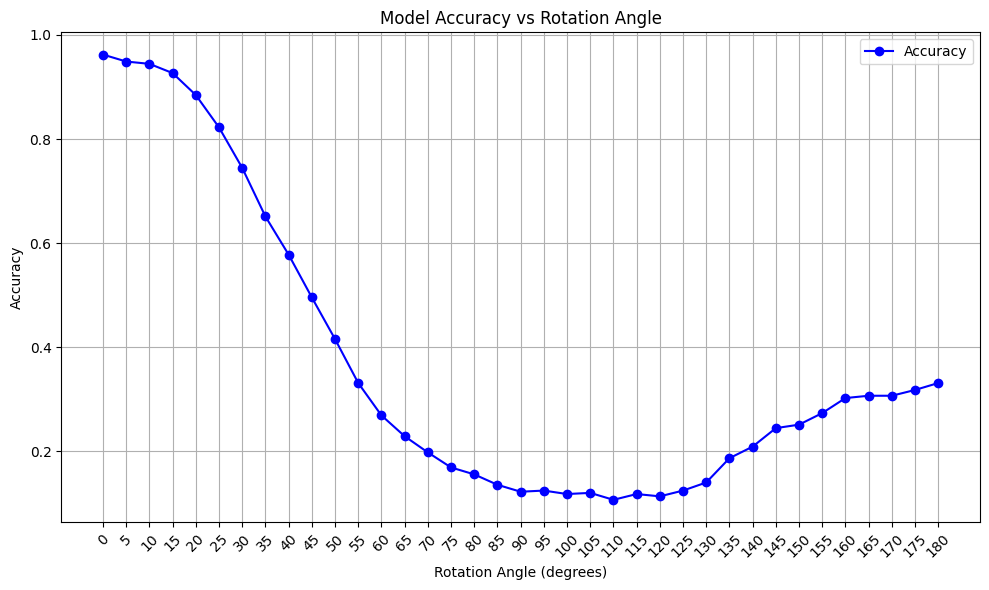

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(rotation_angles, rotation_metrics['overall_accuracy'], marker='o', color='blue', label='Accuracy')
plt.title('Model Accuracy vs Rotation Angle')
plt.xlabel('Rotation Angle (degrees)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.xticks(rotation_angles, rotation=45)
plt.tight_layout()
plt.show()

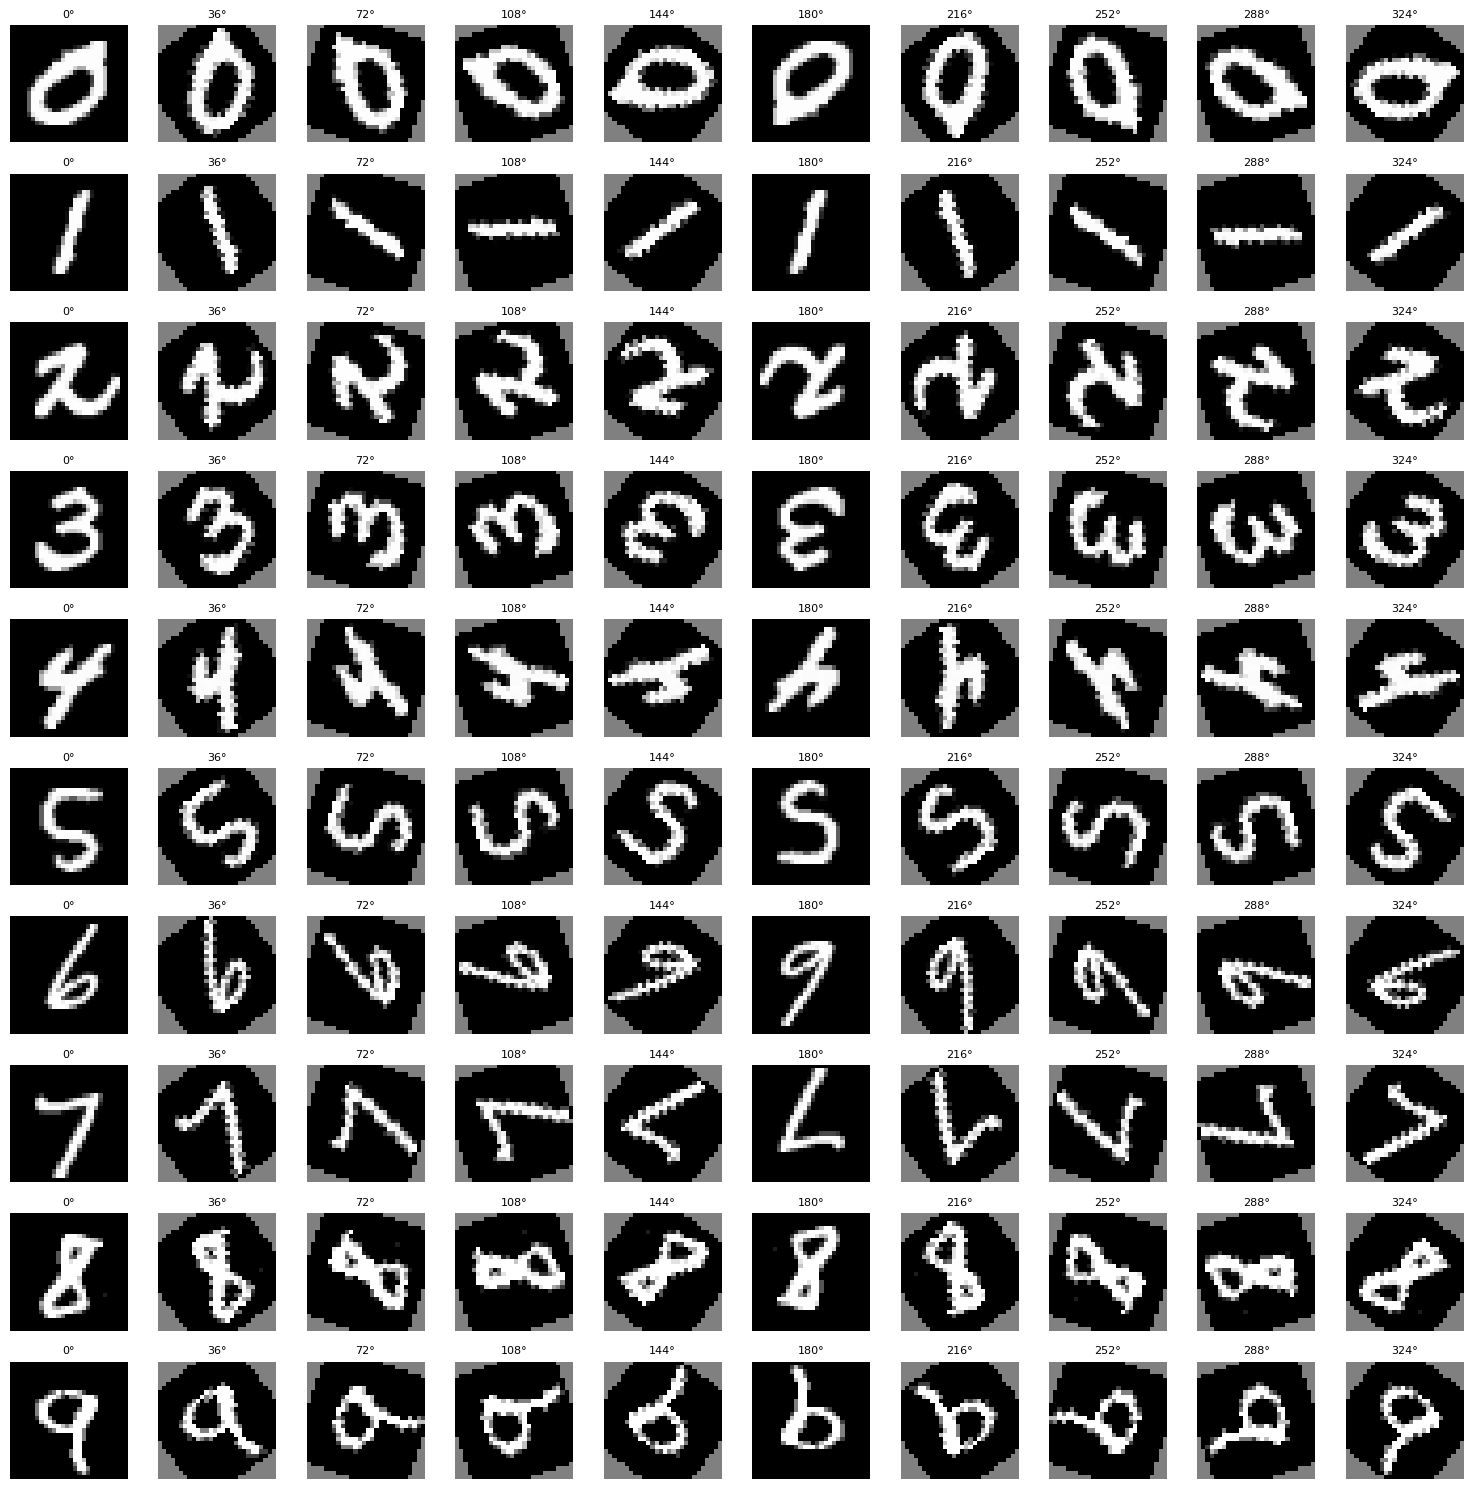

In [ ]:
# Angles to rotate (10 different angles)
rotation_angles = [i * 36 for i in range(10)]

# Collect one sample per class
class_images = defaultdict(list)

# Collect up to 1 image per class
for image, label in test_dataset:
    if len(class_images[label]) < 1:
        class_images[label].append(image)
    if len(class_images) == 10 and all(len(v) == 1 for v in class_images.values()):
        break

# Plotting
fig, axs = plt.subplots(10, 10, figsize=(15, 15))

for class_id in range(10):
    original_image = class_images[class_id][0]
    for i, angle in enumerate(rotation_angles):
        rotated = TF.rotate(original_image, angle)
        axs[class_id, i].imshow(rotated.squeeze(), cmap='gray')
        axs[class_id, i].axis('off')
        axs[class_id, i].set_title(f"{angle}°", fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
import csv

# Define the data (you can replace this with your actual data)
rotation_degrees = [i for i in range(0, 181, 5)]
metrics = [
    {"accuracy": 0.9773, "precision": 0.9798, "recall": 0.9773, "f1_score": 0.9784, "auc": 0.9994},
    {"accuracy": 0.9682, "precision": 0.9680, "recall": 0.9682, "f1_score": 0.9679, "auc": 0.9992},
    {"accuracy": 0.9654, "precision": 0.9678, "recall": 0.9654, "f1_score": 0.9663, "auc": 0.9992},
    {"accuracy": 0.9462, "precision": 0.9468, "recall": 0.9462, "f1_score": 0.9458, "auc": 0.9982},
    {"accuracy": 0.8958, "precision": 0.9036, "recall": 0.8958, "f1_score": 0.8950, "auc": 0.9955},
    {"accuracy": 0.8371, "precision": 0.8489, "recall": 0.8371, "f1_score": 0.8342, "auc": 0.9881},
    {"accuracy": 0.7645, "precision": 0.7830, "recall": 0.7645, "f1_score": 0.7597, "auc": 0.9713},
    {"accuracy": 0.6625, "precision": 0.6746, "recall": 0.6625, "f1_score": 0.6513, "auc": 0.9395},
    {"accuracy": 0.5487, "precision": 0.5370, "recall": 0.5487, "f1_score": 0.5260, "auc": 0.8933},
    {"accuracy": 0.4404, "precision": 0.4227, "recall": 0.4404, "f1_score": 0.4146, "auc": 0.8373},
    {"accuracy": 0.3714, "precision": 0.3821, "recall": 0.3714, "f1_score": 0.3487, "auc": 0.7742},
    {"accuracy": 0.3213, "precision": 0.3163, "recall": 0.3213, "f1_score": 0.2944, "auc": 0.7191},
    {"accuracy": 0.2325, "precision": 0.2482, "recall": 0.2325, "f1_score": 0.2156, "auc": 0.6652},
    {"accuracy": 0.1967, "precision": 0.2187, "recall": 0.1967, "f1_score": 0.1798, "auc": 0.6119},
    {"accuracy": 0.1618, "precision": 0.1805, "recall": 0.1618, "f1_score": 0.1423, "auc": 0.5878},
    {"accuracy": 0.1374, "precision": 0.1228, "recall": 0.1374, "f1_score": 0.1214, "auc": 0.5482},
    {"accuracy": 0.1055, "precision": 0.0942, "recall": 0.1055, "f1_score": 0.0914, "auc": 0.5230},
    {"accuracy": 0.1069, "precision": 0.0989, "recall": 0.1069, "f1_score": 0.0956, "auc": 0.4935},
    {"accuracy": 0.1040, "precision": 0.0946, "recall": 0.1040, "f1_score": 0.0879, "auc": 0.5051},
    {"accuracy": 0.0888, "precision": 0.0784, "recall": 0.0888, "f1_score": 0.0725, "auc": 0.5044},
    {"accuracy": 0.0822, "precision": 0.0638, "recall": 0.0822, "f1_score": 0.0604, "auc": 0.4952},
    {"accuracy": 0.1031, "precision": 0.0967, "recall": 0.1031, "f1_score": 0.0831, "auc": 0.5009},
    {"accuracy": 0.1213, "precision": 0.2036, "recall": 0.1213, "f1_score": 0.1042, "auc": 0.5016},
    {"accuracy": 0.1332, "precision": 0.1975, "recall": 0.1332, "f1_score": 0.1131, "auc": 0.5154},
    {"accuracy": 0.1474, "precision": 0.2070, "recall": 0.1474, "f1_score": 0.1298, "auc": 0.5267},
    {"accuracy": 0.1802, "precision": 0.2206, "recall": 0.1802, "f1_score": 0.1622, "auc": 0.5450},
    {"accuracy": 0.2107, "precision": 0.2353, "recall": 0.2107, "f1_score": 0.1881, "auc": 0.5623},
    {"accuracy": 0.2339, "precision": 0.2412, "recall": 0.2339, "f1_score": 0.2148, "auc": 0.5854},
    {"accuracy": 0.2605, "precision": 0.2582, "recall": 0.2605, "f1_score": 0.2434, "auc": 0.5962},
    {"accuracy": 0.2793, "precision": 0.2600, "recall": 0.2793, "f1_score": 0.2561, "auc": 0.6116},
    {"accuracy": 0.2833, "precision": 0.2619, "recall": 0.2833, "f1_score": 0.2614, "auc": 0.6243},
    {"accuracy": 0.2960, "precision": 0.2621, "recall": 0.2960, "f1_score": 0.2715, "auc": 0.6302},
    {"accuracy": 0.3103, "precision": 0.2906, "recall": 0.3103, "f1_score": 0.2942, "auc": 0.6361},
    {"accuracy": 0.3041, "precision": 0.3122, "recall": 0.3041, "f1_score": 0.2976, "auc": 0.6344},
    {"accuracy": 0.3055, "precision": 0.3418, "recall": 0.3055, "f1_score": 0.3105, "auc": 0.6368},
    {"accuracy": 0.3083, "precision": 0.3544, "recall": 0.3083, "f1_score": 0.3156, "auc": 0.6352},
    {"accuracy": 0.3257, "precision": 0.3743, "recall": 0.3257, "f1_score": 0.3358, "auc": 0.6417}
]

# Prepare header and data rows
header = ["Rotation", "Accuracy", "Precision", "Recall", "F1 Score", "AUC"]
data = []

for degree, metric in zip(rotation_degrees, metrics):
    row = [degree, metric["accuracy"], metric["precision"], metric["recall"], metric["f1_score"], metric["auc"]]
    data.append(row)

# Write to CSV file
with open('rotation_metrics.csv', mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(header)
    writer.writerows(data)

print("CSV file 'rotation_metrics.csv' has been created.")


CSV file 'rotation_metrics.csv' has been created.


In [ ]:
from google.colab import files
files.download('/content/rotation_metrics.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Translation

In [ ]:
# Define translation shifts (±4, ±8, ±12) in X (right & up) and -X (left & down)
translation_shifts = [4, -4, 8, -8, 12, -12]

# Store metrics for each shift
translation_metrics = {
    'class_accuracy': {i: [] for i in range(10)},
    'precision': {i: [] for i in range(10)},
    'recall': {i: [] for i in range(10)},
    'f1': {i: [] for i in range(10)},
    'auc': {i: [] for i in range(10)},
    'avg_accuracy': [],
    'avg_precision': [],
    'avg_recall': [],
    'avg_f1': [],
    'avg_auc': []
}

# Apply each translation
for shift in translation_shifts:
    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for image, label in test_dataset:
            # Apply translation, with positive shifts moving right & up, negative shifts move left & down
            translated = TF.affine(image, angle=0, translate=(shift, shift), scale=1.0, shear=0)
            translated = translated.unsqueeze(0).to(device)
            label = torch.tensor(label).unsqueeze(0).to(device)

            outputs = loaded_model(translated)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(label.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    all_probs = np.array(all_probs)

    # Class-wise metrics
    class_accs, class_precs, class_recs, class_f1s, class_aucs = [], [], [], [], []

    for i in range(10):
        class_idx = np.where(all_targets == i)[0]
        if len(class_idx) > 0:
            correct = np.sum(all_preds[class_idx] == i)
            acc = correct / len(class_idx)
            class_accs.append(acc)
            translation_metrics['class_accuracy'][i].append(acc)

            binary_true = (all_targets == i).astype(int)
            binary_pred = (all_preds == i).astype(int)

            prec = precision_score(binary_true, binary_pred, zero_division=0)
            rec = recall_score(binary_true, binary_pred, zero_division=0)
            f1 = f1_score(binary_true, binary_pred, zero_division=0)

            class_precs.append(prec)
            class_recs.append(rec)
            class_f1s.append(f1)

            translation_metrics['precision'][i].append(prec)
            translation_metrics['recall'][i].append(rec)
            translation_metrics['f1'][i].append(f1)

            try:
                auc = roc_auc_score(binary_true, all_probs[:, i])
            except ValueError:
                auc = float('nan')
            class_aucs.append(auc)
            translation_metrics['auc'][i].append(auc)

    # Average across classes
    translation_metrics['avg_accuracy'].append(np.mean(class_accs))
    translation_metrics['avg_precision'].append(np.mean(class_precs))
    translation_metrics['avg_recall'].append(np.mean(class_recs))
    translation_metrics['avg_f1'].append(np.mean(class_f1s))
    translation_metrics['avg_auc'].append(np.nanmean(class_aucs))

# Summarize results
translation_metrics_output = {
    'shifts': translation_shifts,
    'averages': {
        'accuracy': translation_metrics['avg_accuracy'],
        'precision': translation_metrics['avg_precision'],
        'recall': translation_metrics['avg_recall'],
        'f1': translation_metrics['avg_f1'],
        'auc': translation_metrics['avg_auc'],
    }
}

In [ ]:
# Print the class-wise results for each translation shift
for shift, avg_acc, avg_prec, avg_rec, avg_f1, avg_auc in zip(translation_shifts, translation_metrics['avg_accuracy'],
                                                              translation_metrics['avg_precision'],
                                                              translation_metrics['avg_recall'],
                                                              translation_metrics['avg_f1'],
                                                              translation_metrics['avg_auc']):
    print(f"\nResults for Shift {shift}:")
    print(f"  Average Accuracy: {avg_acc:.4f}")
    print(f"  Average Precision: {avg_prec:.4f}")
    print(f"  Average Recall: {avg_rec:.4f}")
    print(f"  Average F1 Score: {avg_f1:.4f}")
    print(f"  Average AUC: {avg_auc:.4f}")

    # Class-wise results
    for i in range(10):
        print(f"\nClass {i} Metrics for Shift {shift}:")
        print(f"  Accuracy: {np.mean(translation_metrics['class_accuracy'][i]):.4f}")
        print(f"  Precision: {np.mean(translation_metrics['precision'][i]):.4f}")
        print(f"  Recall: {np.mean(translation_metrics['recall'][i]):.4f}")
        print(f"  F1 Score: {np.mean(translation_metrics['f1'][i]):.4f}")
        print(f"  AUC: {np.mean(translation_metrics['auc'][i]):.4f}")

# Print the overall average results for all translation shifts
print("\nOverall Average Metrics:")
print(f"  Average Accuracy: {np.mean(translation_metrics['avg_accuracy']):.4f}")
print(f"  Average Precision: {np.mean(translation_metrics['avg_precision']):.4f}")
print(f"  Average Recall: {np.mean(translation_metrics['avg_recall']):.4f}")
print(f"  Average F1 Score: {np.mean(translation_metrics['avg_f1']):.4f}")
print(f"  Average AUC: {np.nanmean(translation_metrics['avg_auc']):.4f}")


Shift 4:
  Average Accuracy: 0.1300
  Average Precision: 0.1345
  Average Recall: 0.1300
  Average F1 Score: 0.1169
  Average AUC: 0.5708

Class 0 Metrics for Shift 4:
  Accuracy: 0.0714
  Precision: 0.0324
  Recall: 0.0714
  F1 Score: 0.0442
  AUC: 0.4288

Class 1 Metrics for Shift 4:
  Accuracy: 0.0000
  Precision: 0.0000
  Recall: 0.0000
  F1 Score: 0.0000
  AUC: 0.4287

Class 2 Metrics for Shift 4:
  Accuracy: 0.1899
  Precision: 0.0733
  Recall: 0.1899
  F1 Score: 0.1010
  AUC: 0.4550

Class 3 Metrics for Shift 4:
  Accuracy: 0.2000
  Precision: 0.1358
  Recall: 0.2000
  F1 Score: 0.1585
  AUC: 0.5357

Class 4 Metrics for Shift 4:
  Accuracy: 0.0789
  Precision: 0.1412
  Recall: 0.0789
  F1 Score: 0.0891
  AUC: 0.5487

Class 5 Metrics for Shift 4:
  Accuracy: 0.2500
  Precision: 0.0884
  Recall: 0.2500
  F1 Score: 0.1083
  AUC: 0.4828

Class 6 Metrics for Shift 4:
  Accuracy: 0.0128
  Precision: 0.0075
  Recall: 0.0128
  F1 Score: 0.0094
  AUC: 0.2342

Class 7 Metrics for Shift 4

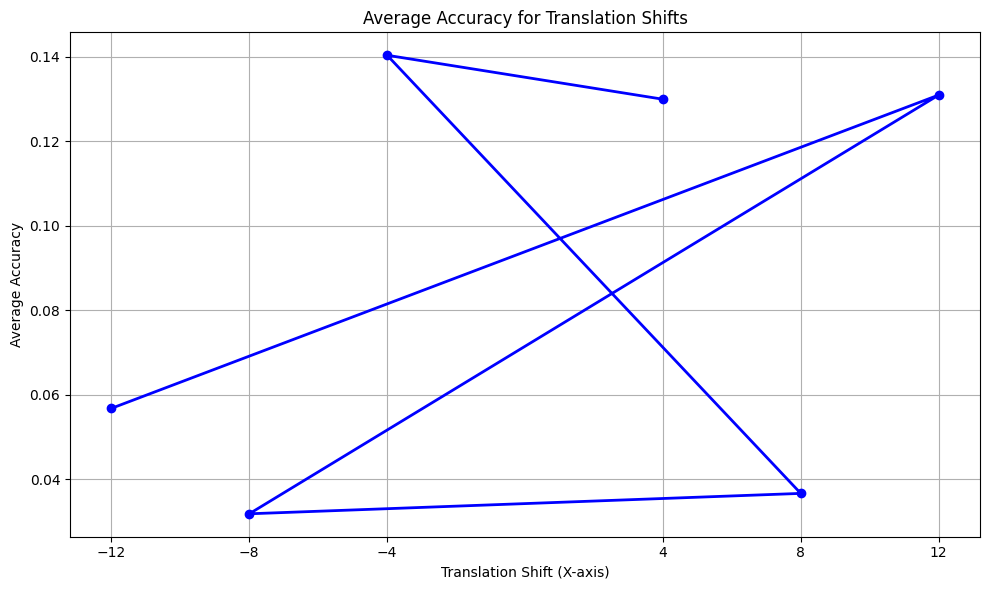

In [ ]:
def plot_average_accuracy(translation_metrics):
    translation_shifts = [4, -4, 8, -8, 12, -12]  # Specific shifts
    avg_accuracy = translation_metrics['avg_accuracy']  # Average accuracy for each shift

    plt.figure(figsize=(10, 6))
    plt.plot(translation_shifts, avg_accuracy, marker='o', color='blue', linestyle='-', linewidth=2)

    # Labeling the plot
    plt.title('Average Accuracy for Translation Shifts')
    plt.xlabel('Translation Shift (X-axis)')
    plt.ylabel('Average Accuracy')
    plt.xticks(translation_shifts)  # Explicitly set x-axis ticks
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Call the function to plot average accuracy
plot_average_accuracy(translation_metrics)

Displaying images for Class 0


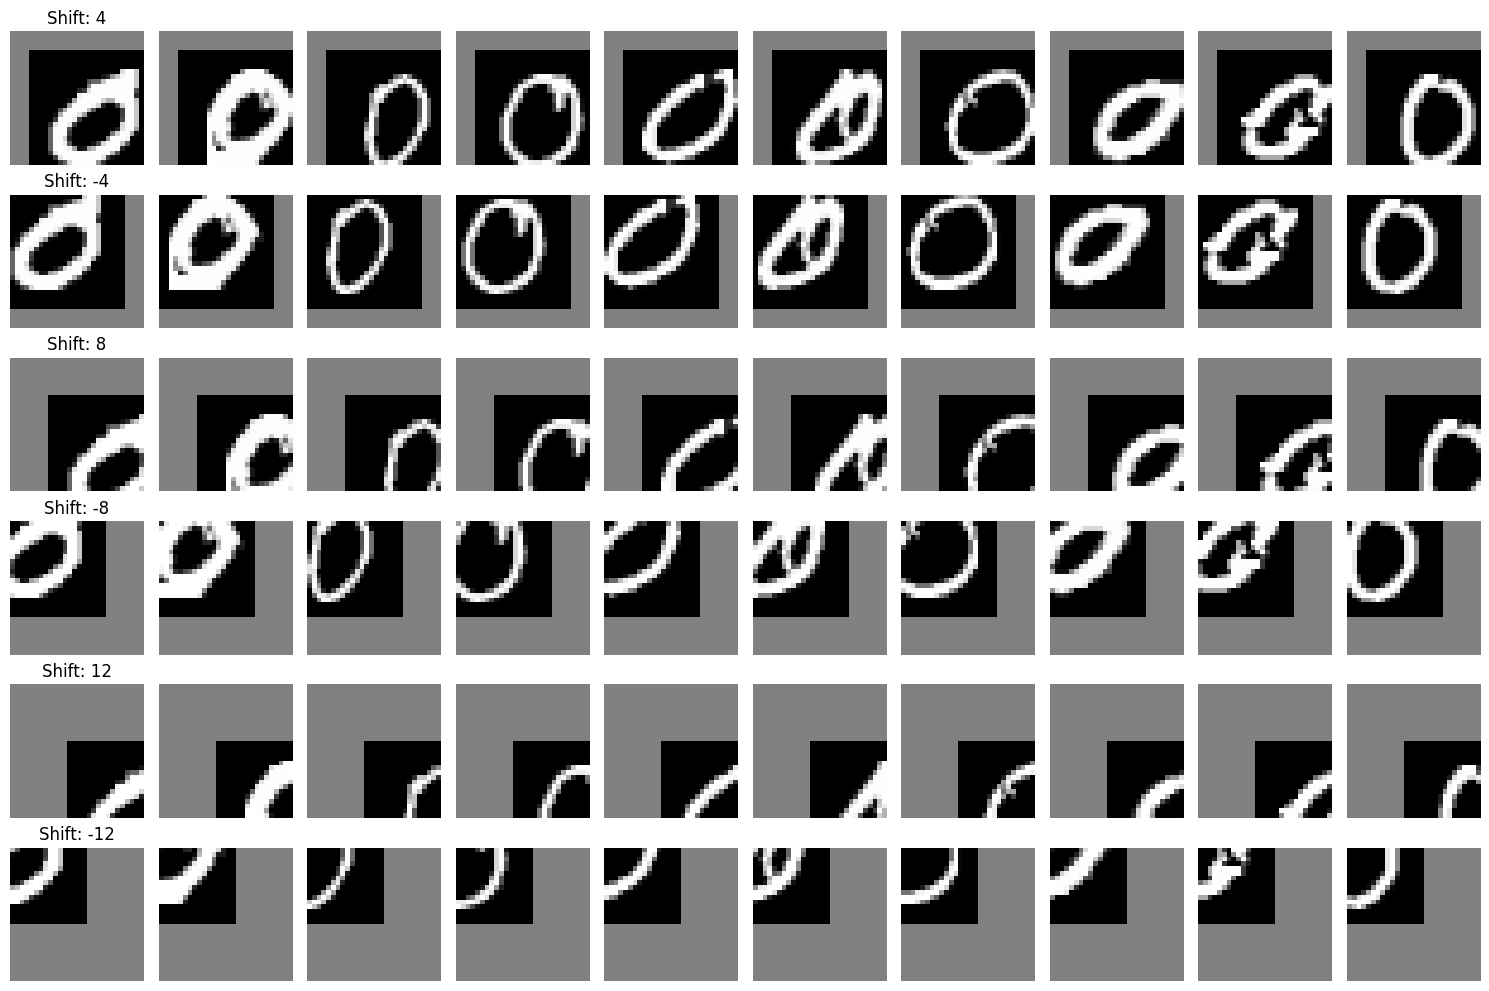

Displaying images for Class 1


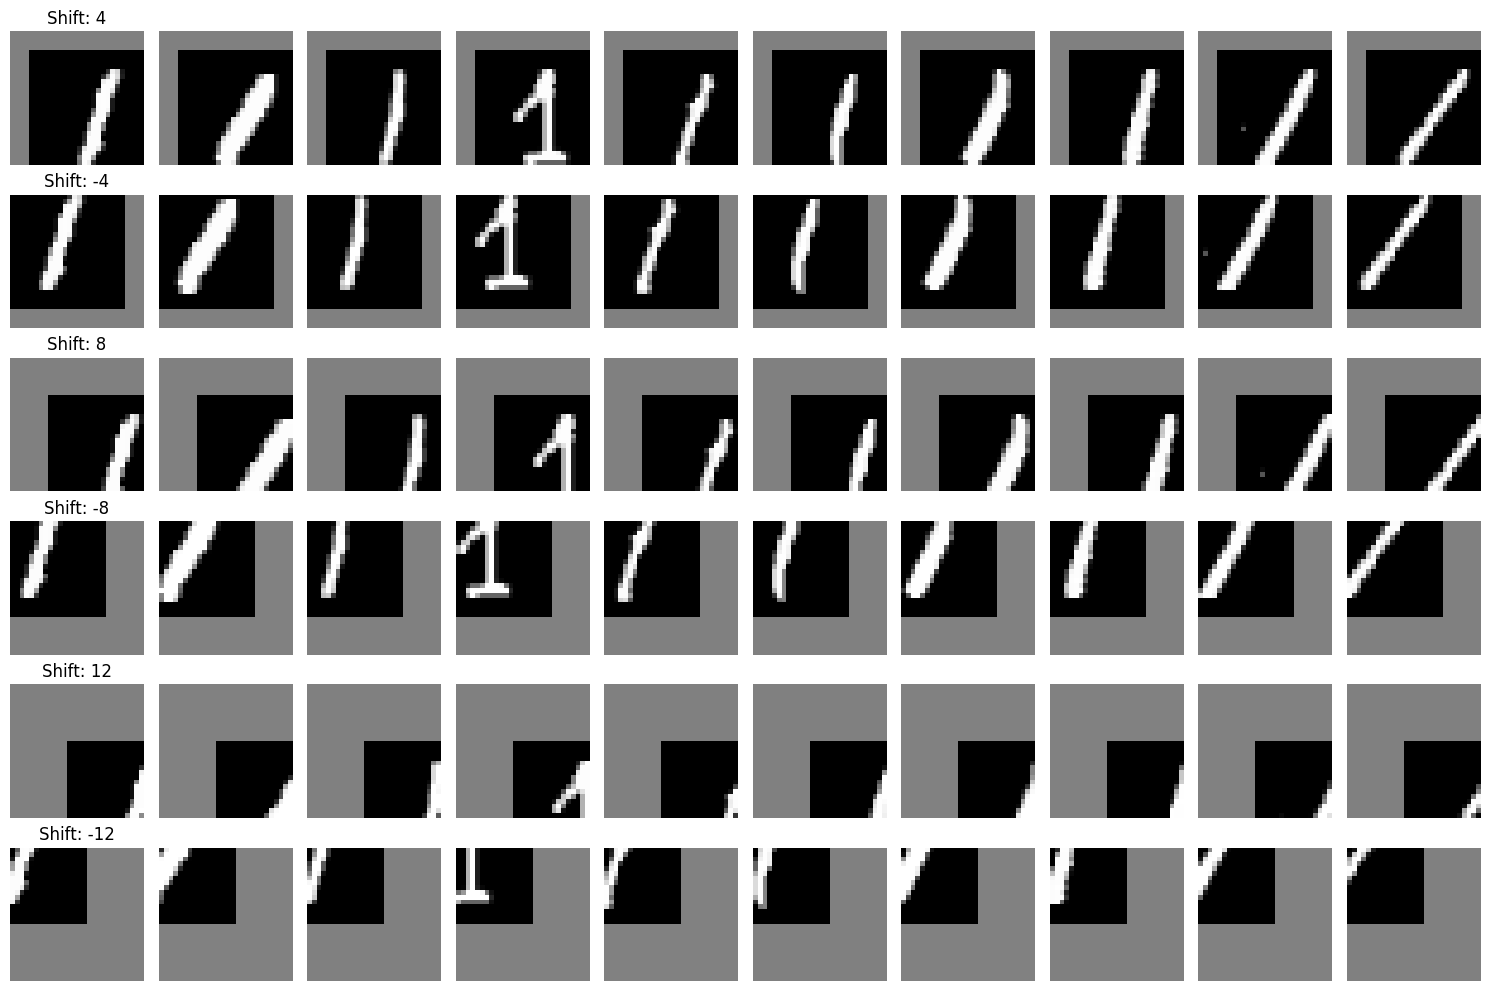

Displaying images for Class 2


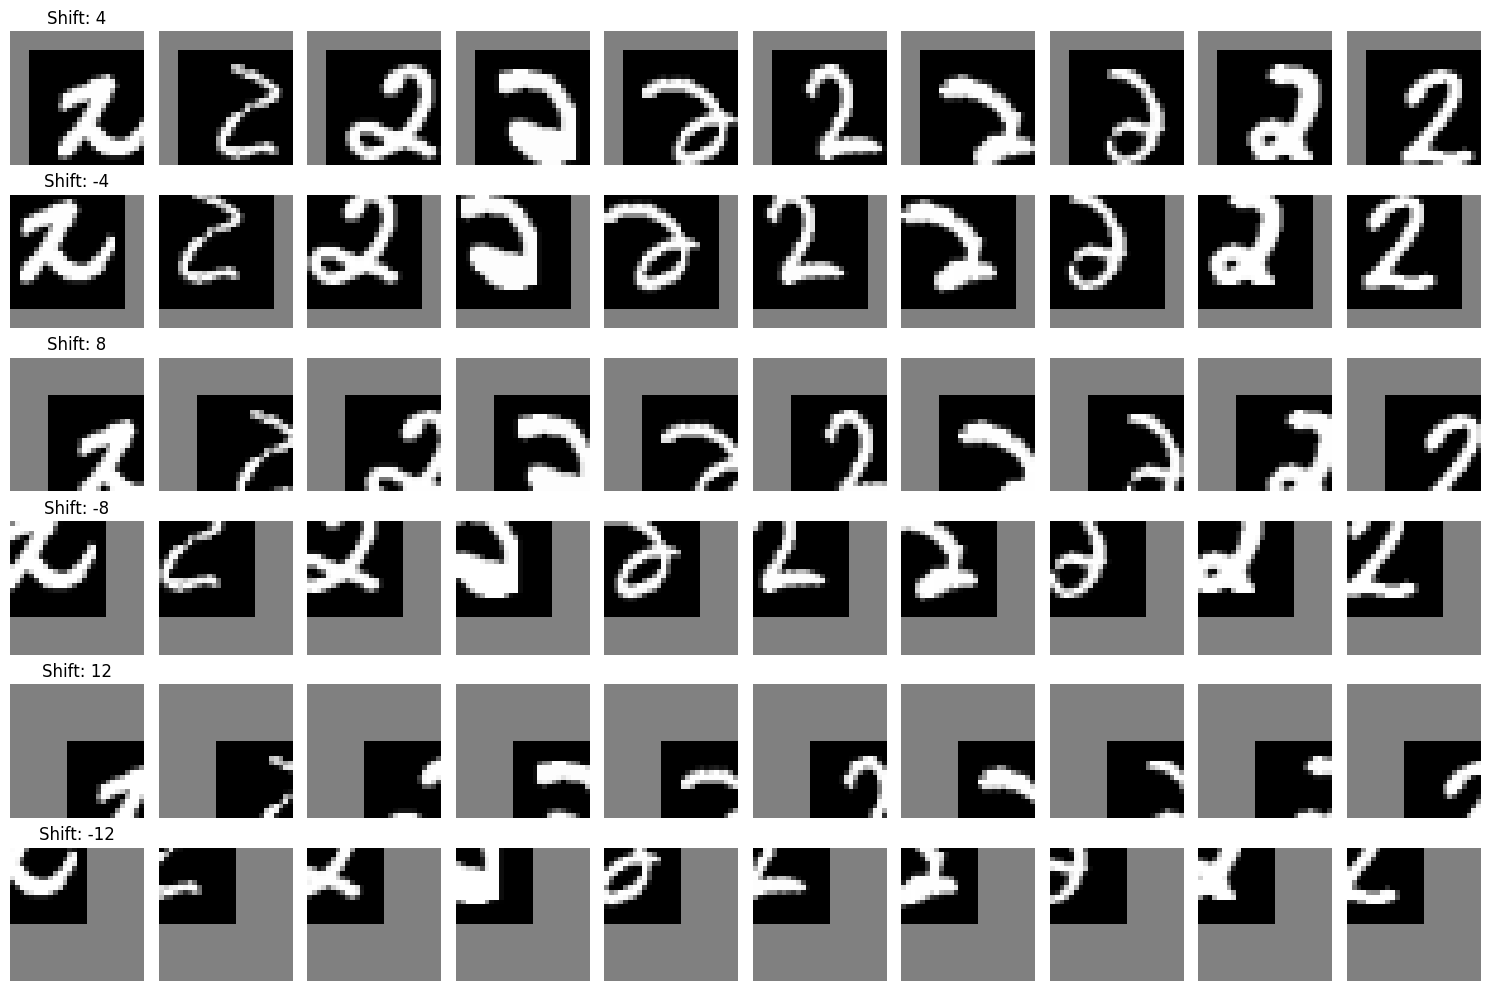

Displaying images for Class 3


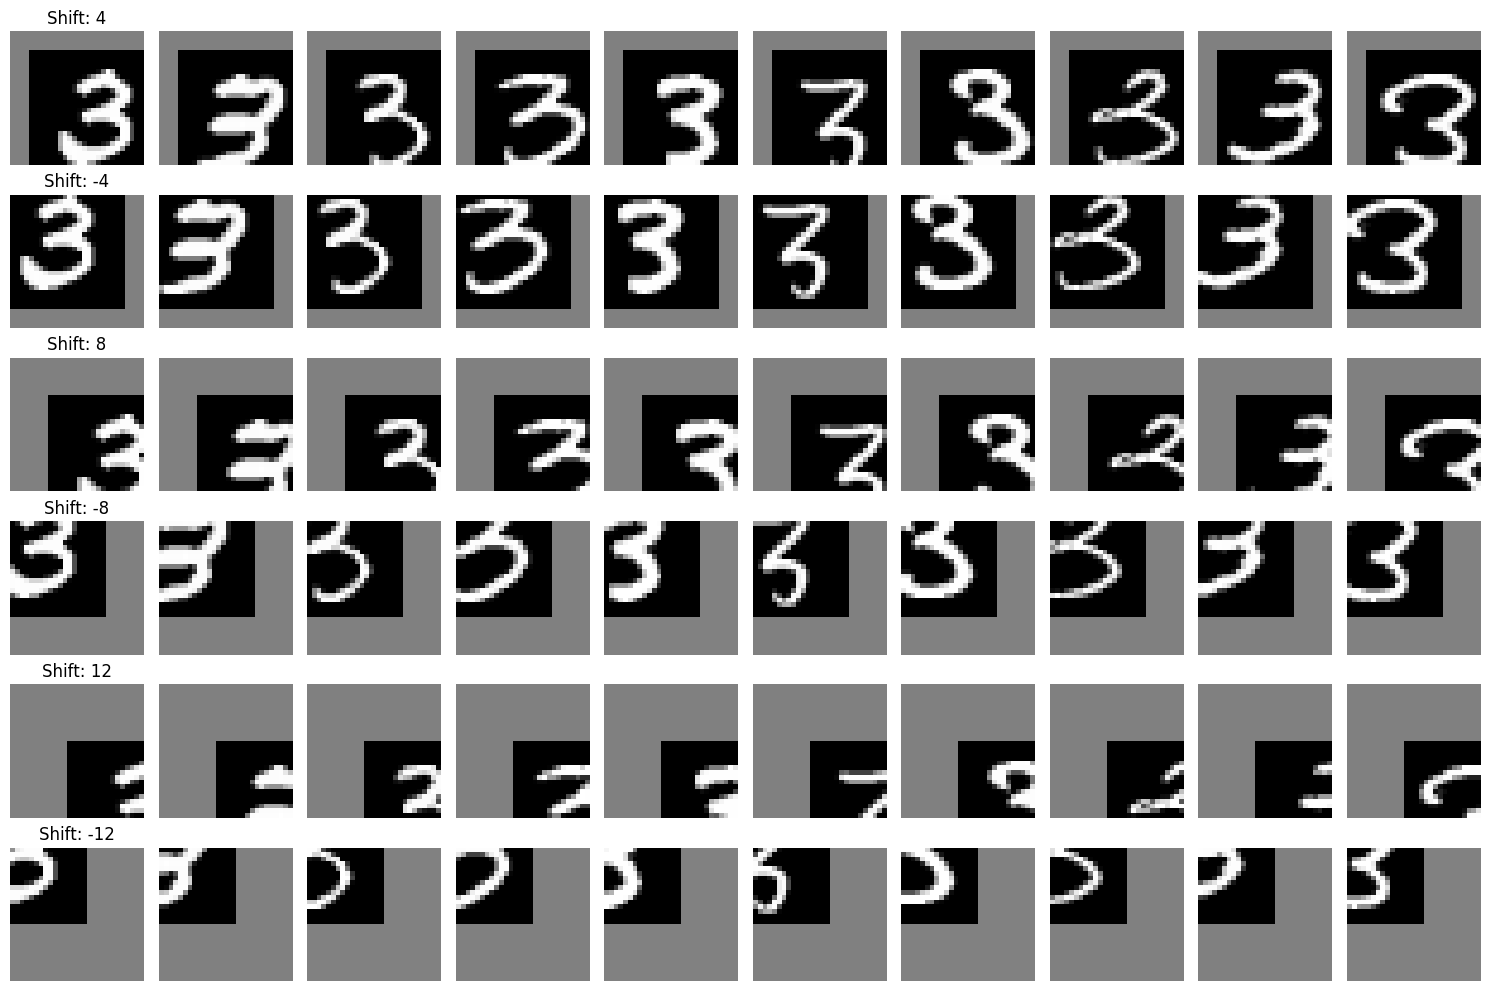

Displaying images for Class 4


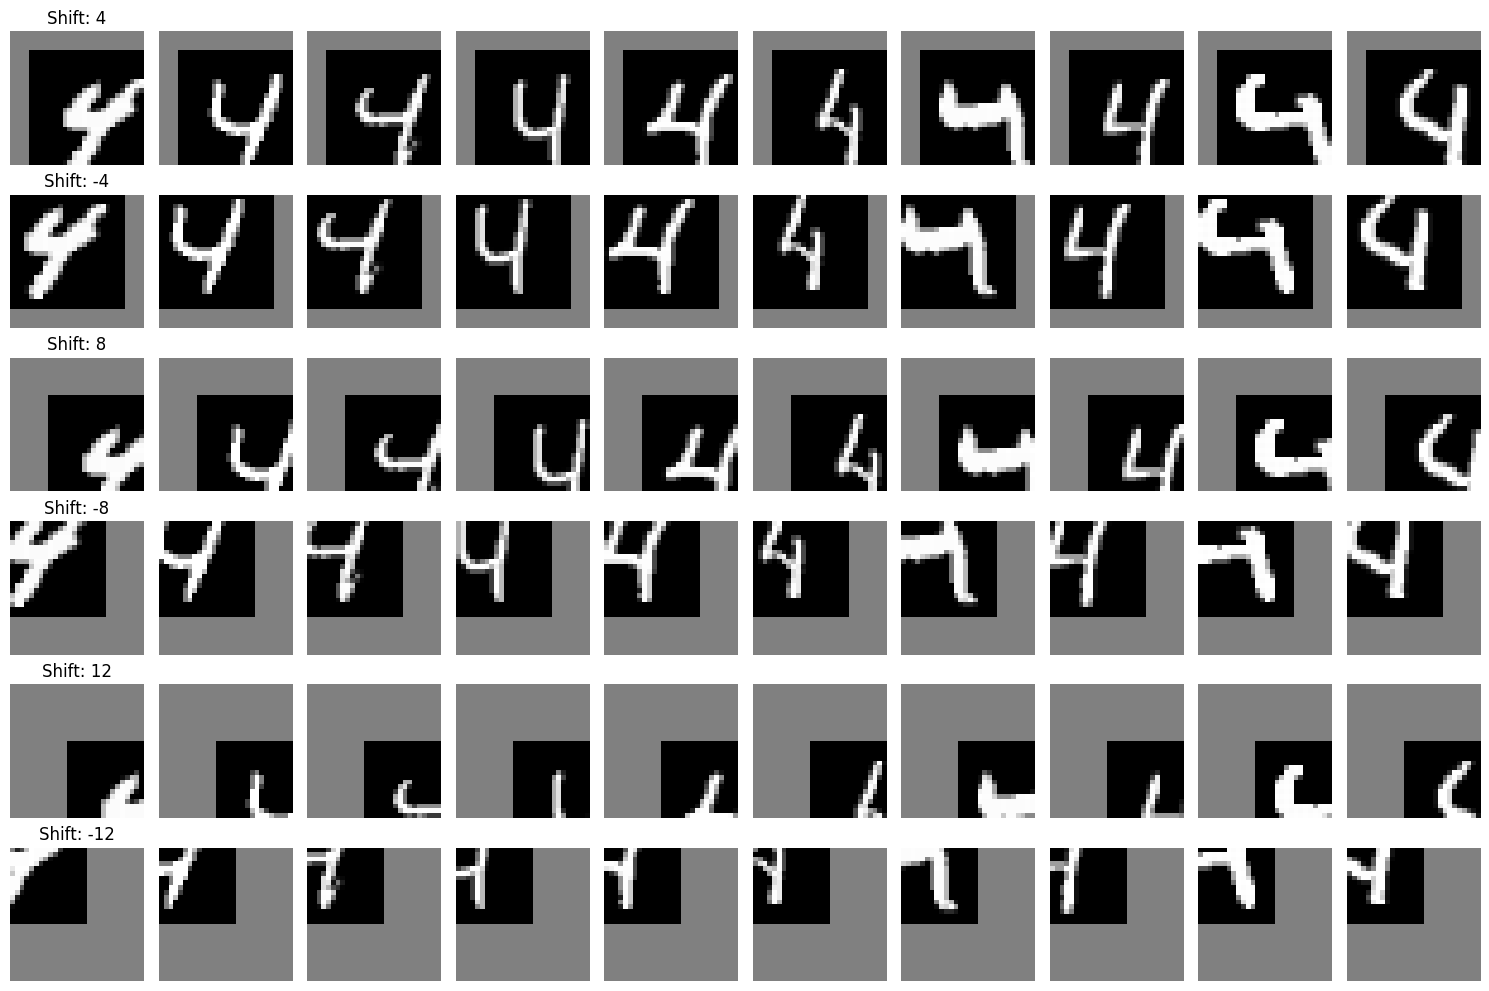

Displaying images for Class 5


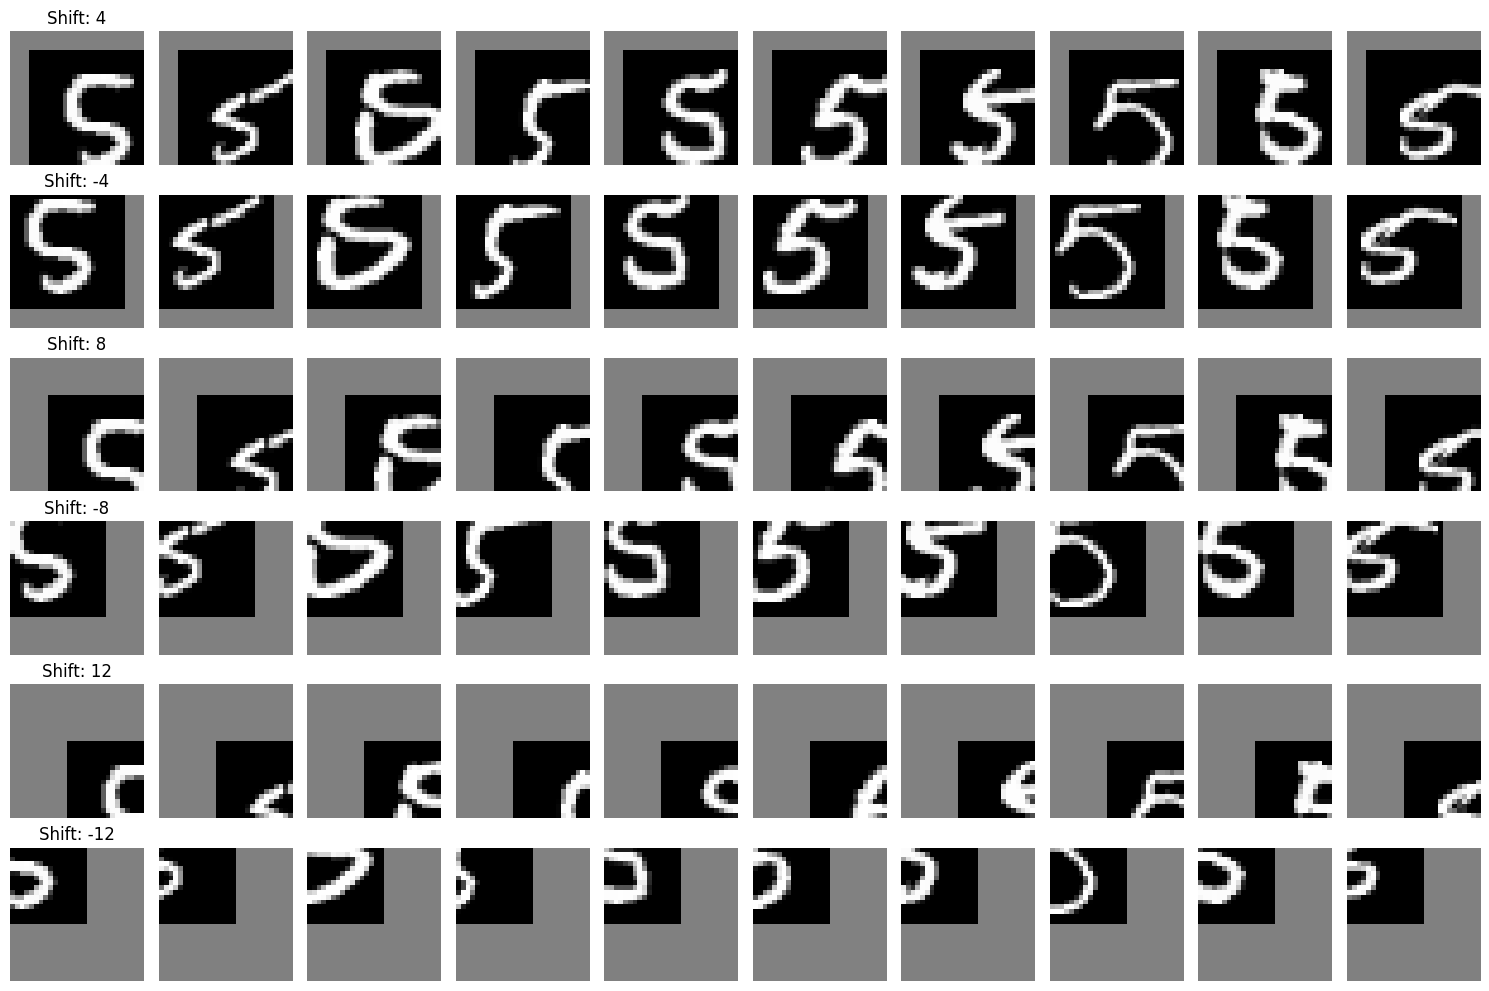

Displaying images for Class 6


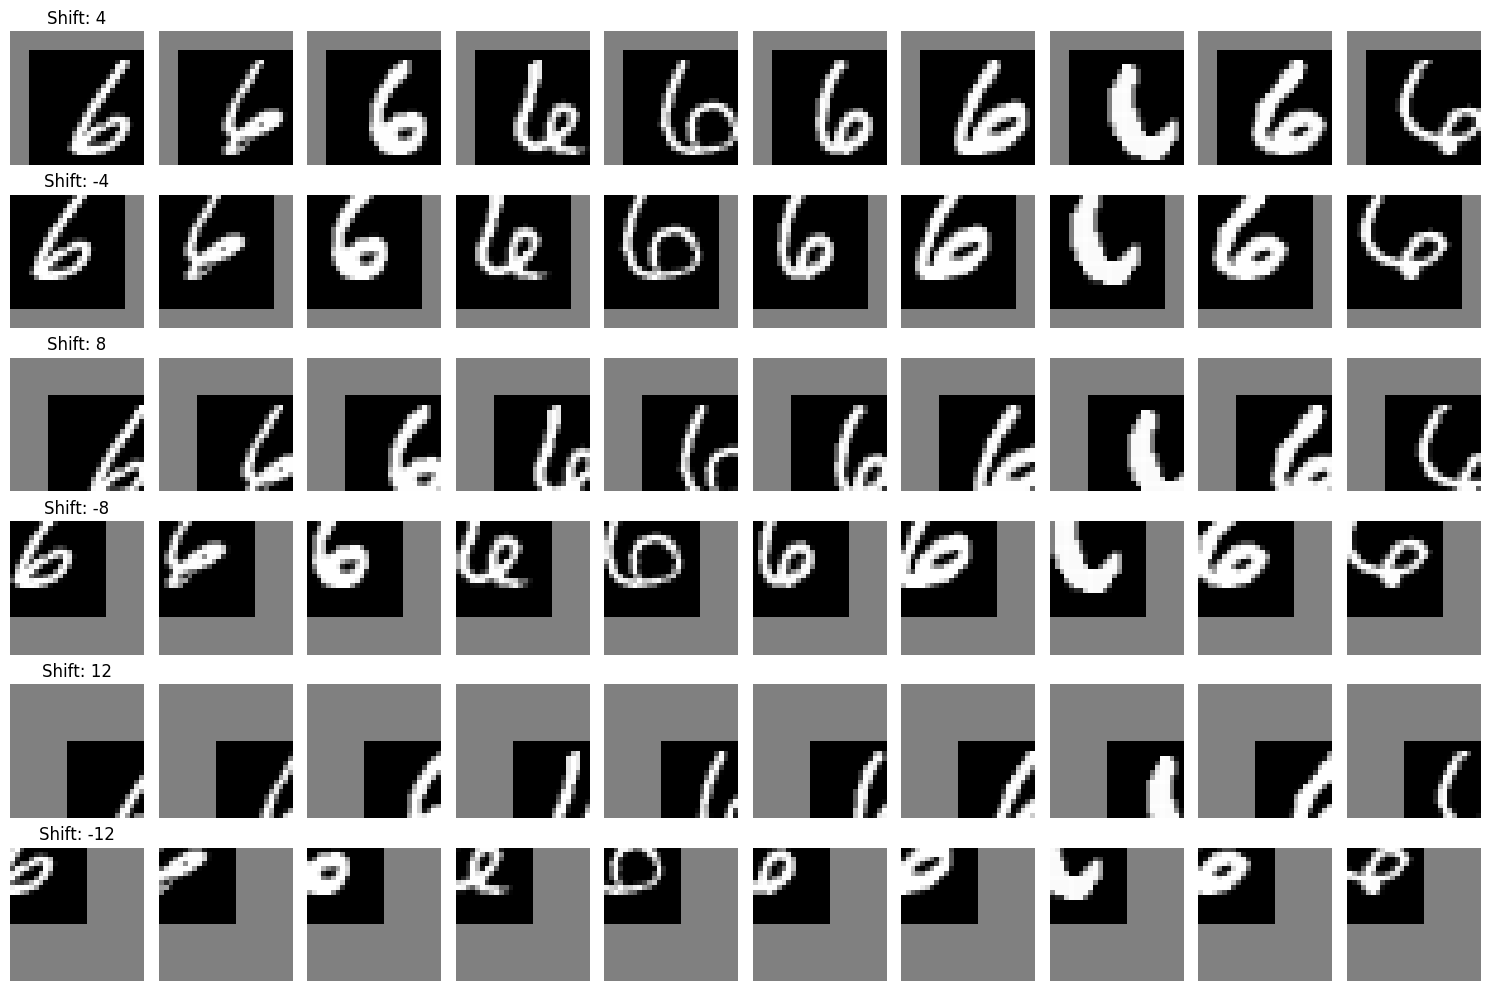

Displaying images for Class 7


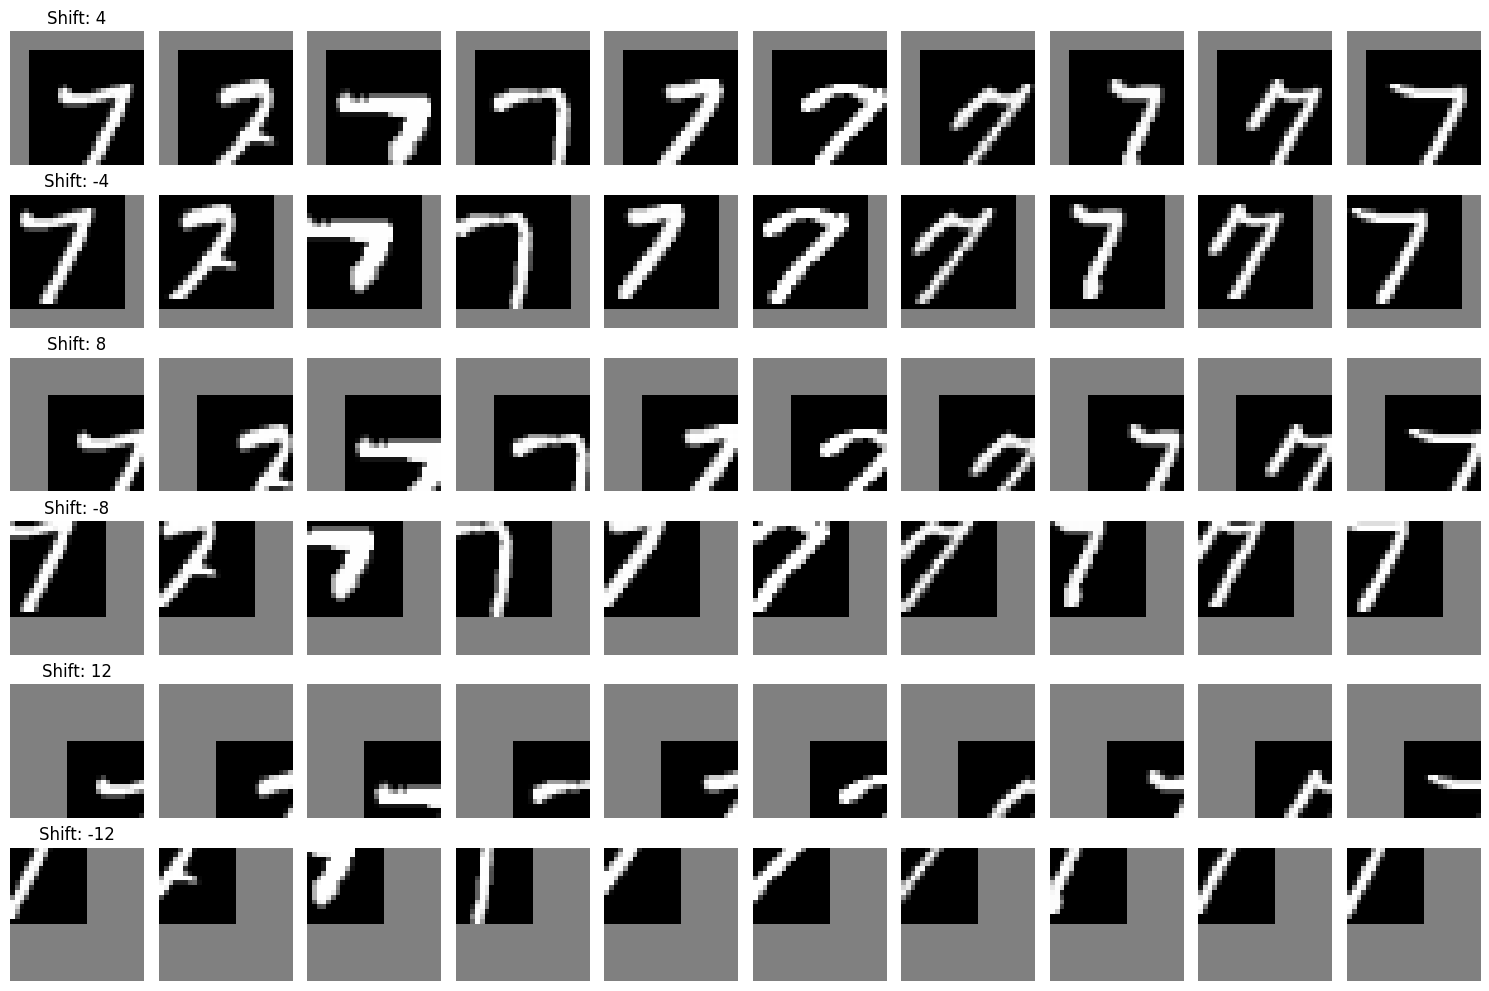

Displaying images for Class 8


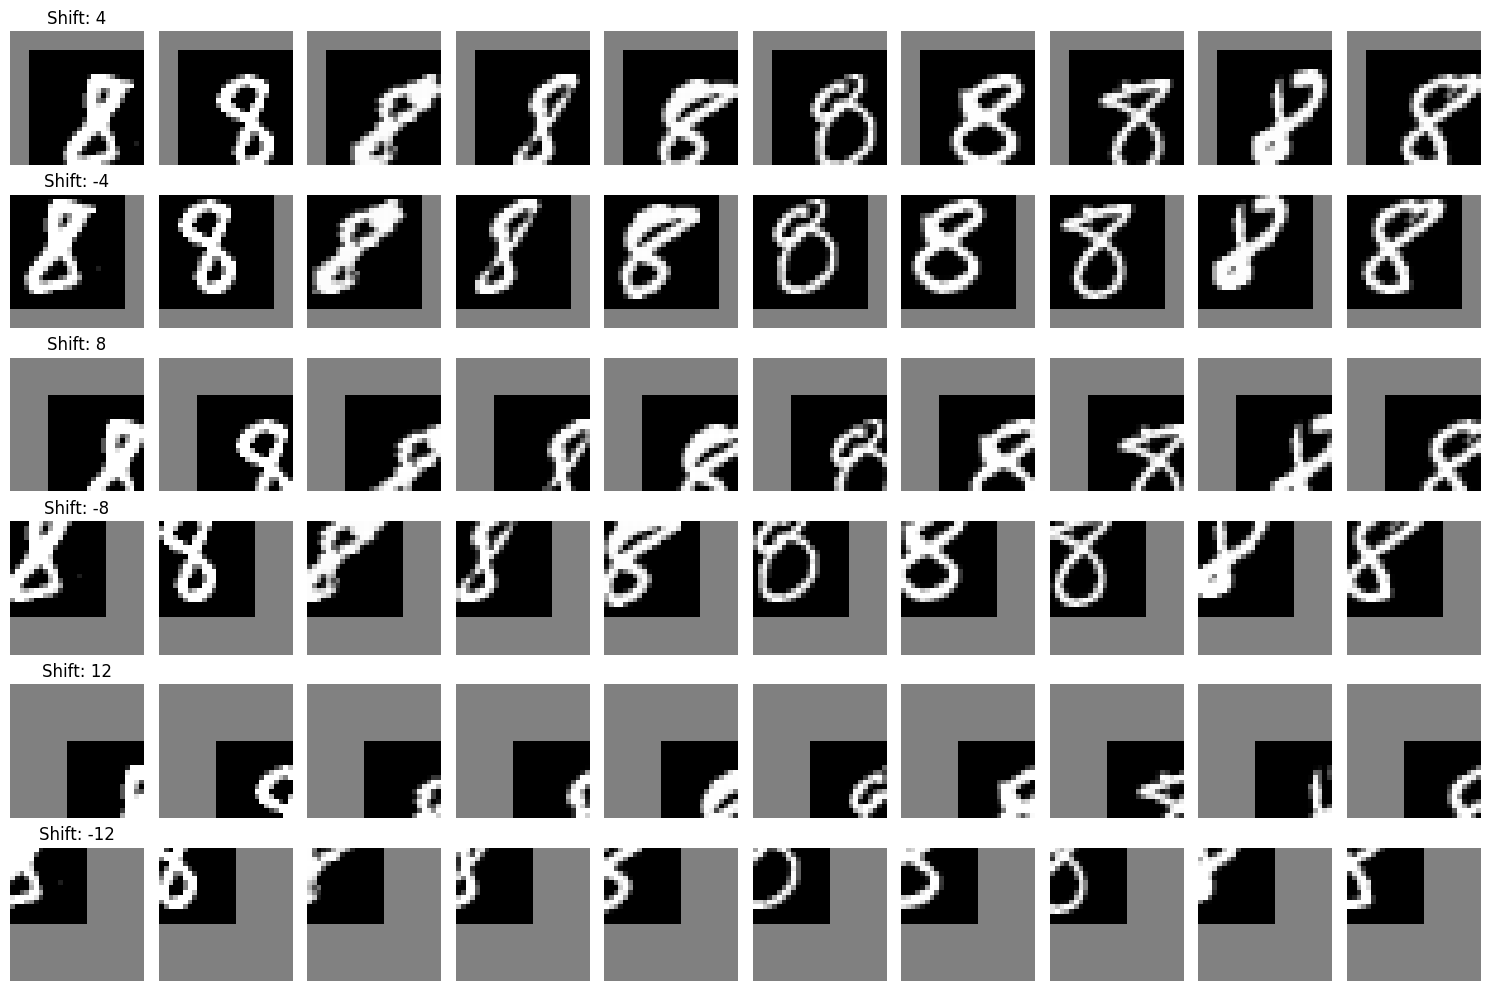

Displaying images for Class 9


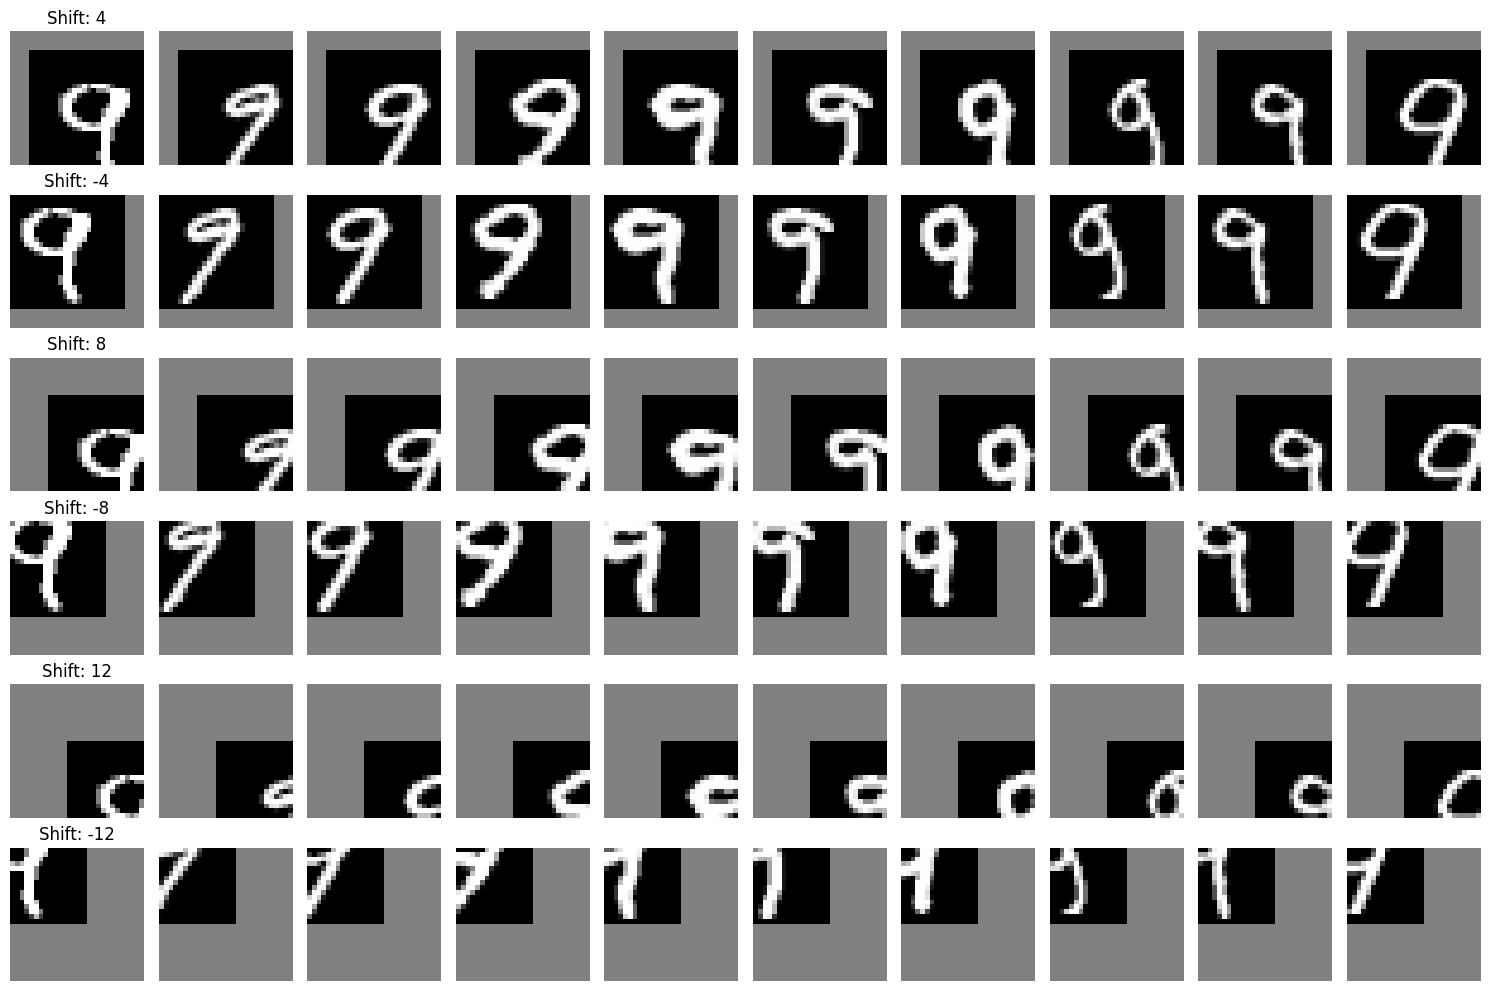

In [ ]:
import matplotlib.pyplot as plt

# Function to plot images
def plot_images(images, labels, shifts, class_id):
    fig, axes = plt.subplots(len(shifts), 10, figsize=(15, 10))
    for i, shift in enumerate(shifts):
        for j in range(10):
            # Apply the translation shift
            translated = TF.affine(images[j], angle=0, translate=(shift, shift), scale=1.0, shear=0)

            # Plot the translated image
            ax = axes[i, j]
            ax.imshow(translated.squeeze(0), cmap='gray')
            ax.axis('off')
            if j == 0:
                ax.set_title(f'Shift: {shift}')
            if i == len(shifts) - 1:
                ax.set_xlabel(f'Label: {labels[j]}')

    plt.tight_layout()
    plt.show()

# Select 10 images from each class in the test dataset
class_images = {i: [] for i in range(10)}
class_labels = {i: [] for i in range(10)}

for image, label in test_dataset:
    if len(class_images[label]) < 10:
        class_images[label].append(image)
        class_labels[label].append(label)

    # Stop once 10 images are collected for each class
    if all(len(class_images[i]) == 10 for i in range(10)):
        break

# Plot images for each class at different shifts
for class_id in range(10):
    print(f"Displaying images for Class {class_id}")
    plot_images(class_images[class_id], class_labels[class_id], translation_shifts, class_id)


In [ ]:
for i in range(len(all_preds)):
    if all_targets[i] == 1:  # Class 1
        print(f"Predicted: {all_preds[i]}, Actual: {all_targets[i]}, Probabilities: {all_probs[i]}")


Predicted: 2, Actual: 1, Probabilities: [0.02554272 0.04621822 0.47404134 0.36644894 0.01959735 0.00708783
 0.00260462 0.03853435 0.01265795 0.00726674]
Predicted: 2, Actual: 1, Probabilities: [0.03329059 0.06286713 0.6187736  0.19482711 0.03430054 0.00535502
 0.00389499 0.02334085 0.01549307 0.00785706]
Predicted: 2, Actual: 1, Probabilities: [0.03059353 0.05749748 0.49620208 0.31654853 0.02703222 0.00911962
 0.0038418  0.03138929 0.0175416  0.01023383]
Predicted: 7, Actual: 1, Probabilities: [2.6430653e-03 8.0002127e-03 1.0404236e-01 3.0363297e-01 2.6755272e-03
 1.1685258e-03 9.9198303e-05 5.7495087e-01 1.8981813e-03 8.8916934e-04]
Predicted: 2, Actual: 1, Probabilities: [0.04225221 0.06519782 0.45290518 0.30699515 0.03856921 0.01336156
 0.00576669 0.0318467  0.02561976 0.0174858 ]
Predicted: 2, Actual: 1, Probabilities: [0.03199826 0.06088956 0.41778195 0.36838624 0.02958098 0.0116024
 0.0040014  0.04452461 0.0181244  0.01311018]
Predicted: 2, Actual: 1, Probabilities: [0.02294082 0

In [ ]:
import pandas as pd

# Data for the shifts and classes
data = {
    'Translation': ['(+)4', '(-)4', '(+)8', '(-)8', '(+)12', '(-)12'],
    'Class 0': [0.0714, 0.0714, 0.0714, 0.0714, 0.0714, 0.0714],
    'Class 1': [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
    'Class 2': [0.1899, 0.1899, 0.1899, 0.1899, 0.1899, 0.1899],
    'Class 3': [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.2000],
    'Class 4': [0.0789, 0.0789, 0.0789, 0.0789, 0.0789, 0.0789],
    'Class 5': [0.2500, 0.2500, 0.2500, 0.2500, 0.2500, 0.2500],
    'Class 6': [0.0128, 0.0128, 0.0128, 0.0128, 0.0128, 0.0128],
    'Class 7': [0.0556, 0.0556, 0.0556, 0.0556, 0.0556, 0.0556],
    'Class 8': [0.0128, 0.0128, 0.0128, 0.0128, 0.0128, 0.0128],
    'Class 9': [0.0060, 0.0060, 0.0060, 0.0060, 0.0060, 0.0060],
    'Average accuracy': [0.1300, 0.1404, 0.0366, 0.0318, 0.1310, 0.0568],
    'Average Precision': [0.1345, 0.1245, 0.0132, 0.0178, 0.0281, 0.0307],
    'Average Recall': [0.1300, 0.1404, 0.0366, 0.0318, 0.1310, 0.0568],
    'Average F1-Score': [0.1169, 0.1143, 0.0193, 0.0226, 0.0424, 0.0315],
    'Average AUC': [0.5708, 0.5444, 0.3486, 0.3453, 0.4647, 0.4666]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Save to CSV
df.to_csv('shift_metrics.csv', index=False)

# Display the DataFrame
df


,Translation,Class 0,Class 1,Class 2,Class 3,Class 4,Class 5,Class 6,Class 7,Class 8,Class 9,Average accuracy,Average Precision,Average Recall,Average F1-Score,Average AUC
0,(+)4,0.0714,0.0,0.1899,0.2,0.0789,0.25,0.0128,0.0556,0.0128,0.006,0.1300,0.1345,0.1300,0.1169,0.5708
1,(-)4,0.0714,0.0,0.1899,0.2,0.0789,0.25,0.0128,0.0556,0.0128,0.006,0.1404,0.1245,0.1404,0.1143,0.5444
2,(+)8,0.0714,0.0,0.1899,0.2,0.0789,0.25,0.0128,0.0556,0.0128,0.006,0.0366,0.0132,0.0366,0.0193,0.3486
3,(-)8,0.0714,0.0,0.1899,0.2,0.0789,0.25,0.0128,0.0556,0.0128,0.006,0.0318,0.0178,0.0318,0.0226,0.3453
4,(+)12,0.0714,0.0,0.1899,0.2,0.0789,0.25,0.0128,0.0556,0.0128,0.006,0.1310,0.0281,0.1310,0.0424,0.4647
5,(-)12,0.0714,0.0,0.1899,0.2,0.0789,0.25,0.0128,0.0556,0.0128,0.006,0.0568,0.0307,0.0568,0.0315,0.4666


In [ ]:
from google.colab import files
files.download('shift_metrics.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Scaling

In [ ]:
# Scaling factors to test
scaling_factors = [0.5, 1.0, 1.5, 2.0]

# Initialize results dictionary
class_wise_scaling_results = {
    scale: {
        i: {
            f"accuracy_{scale}": 0,
            f"precision_{scale}": 0,
            f"recall_{scale}": 0,
            f"f1_score_{scale}": 0,
            f"auc_{scale}": 0
        } for i in range(10)
    } for scale in scaling_factors
}

# Scaling function to resize the image
def scale_image(image_tensor, scale_factor):
    c, h, w = image_tensor.shape
    new_h = int(h * scale_factor)
    new_w = int(w * scale_factor)

    # Resize the image
    image_resized = TF.resize(image_tensor, [new_h, new_w])

    # Pad or crop back to 28x28
    image_padded = TF.center_crop(TF.pad(image_resized, padding=(
        max((28 - new_w) // 2, 0),
        max((28 - new_h) // 2, 0),
        max((28 - new_w + 1) // 2, 0),
        max((28 - new_h + 1) // 2, 0)
    )), [28, 28])

    return image_padded

# Loop through each scaling factor
for scale in scaling_factors:
    scaled_images = []
    scaled_labels = []

    # Apply scaling to each image in the test dataset
    for image, label in test_dataset:
        scaled = scale_image(image, scale)
        scaled_images.append(scaled)
        scaled_labels.append(label)

    scaled_loader = DataLoader(list(zip(scaled_images, scaled_labels)), batch_size=64)

    all_preds = []
    all_targets = []
    all_probs = []

    # Inference loop
    with torch.no_grad():
        for images, labels in scaled_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = loaded_model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())
            probs = F.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())

    # Per-class metrics
    for i in range(10):
        class_idx = np.where(np.array(all_targets) == i)[0]
        if len(class_idx) > 0:
            # Calculate accuracy for class i
            acc = np.mean(np.array(all_preds)[class_idx] == i)

            # Calculate precision, recall, F1-score, and AUC for class i
            precision = precision_score(all_targets, all_preds, labels=[i], average='weighted', zero_division=0)
            recall = recall_score(all_targets, all_preds, labels=[i], average='weighted', zero_division=0)
            f1 = f1_score(all_targets, all_preds, labels=[i], average='weighted', zero_division=0)
            try:
                auc = roc_auc_score(all_targets, all_probs, multi_class='ovr', average='weighted')
            except ValueError:
                auc = float('nan')

            # Store results in the dictionary
            class_wise_scaling_results[scale][i][f'accuracy_{scale}'] += acc
            class_wise_scaling_results[scale][i][f'precision_{scale}'] += precision
            class_wise_scaling_results[scale][i][f'recall_{scale}'] += recall
            class_wise_scaling_results[scale][i][f'f1_score_{scale}'] += f1
            class_wise_scaling_results[scale][i][f'auc_{scale}'] += auc

# Print the results for each scaling factor and each class
for scale in scaling_factors:
    print(f"\nResults for scaling factor {scale}:")
    for i in range(10):
        print(f"\nClass {i}:")
        print(f"  Accuracy: {class_wise_scaling_results[scale][i][f'accuracy_{scale}']:.4f}")
        print(f"  Precision: {class_wise_scaling_results[scale][i][f'precision_{scale}']:.4f}")
        print(f"  Recall: {class_wise_scaling_results[scale][i][f'recall_{scale}']:.4f}")
        print(f"  F1 Score: {class_wise_scaling_results[scale][i][f'f1_score_{scale}']:.4f}")
        print(f"  AUC: {class_wise_scaling_results[scale][i][f'auc_{scale}']:.4f}")

# Calculate the average metrics for each scaling factor
for scale in scaling_factors:
    avg_accuracy = np.mean([class_wise_scaling_results[scale][i][f'accuracy_{scale}'] for i in range(10)])
    avg_precision = np.mean([class_wise_scaling_results[scale][i][f'precision_{scale}'] for i in range(10)])
    avg_recall = np.mean([class_wise_scaling_results[scale][i][f'recall_{scale}'] for i in range(10)])
    avg_f1 = np.mean([class_wise_scaling_results[scale][i][f'f1_score_{scale}'] for i in range(10)])
    avg_auc = np.mean([class_wise_scaling_results[scale][i][f'auc_{scale}'] for i in range(10)]) if any(class_wise_scaling_results[scale][i][f'auc_{scale}'] for i in range(10)) else float('nan')

    print(f"\nAverage Metrics for scaling factor {scale}:")
    print(f"  Average Accuracy: {avg_accuracy:.4f}")
    print(f"  Average Precision: {avg_precision:.4f}")
    print(f"  Average Recall: {avg_recall:.4f}")
    print(f"  Average F1 Score: {avg_f1:.4f}")
    print(f"  Average AUC: {avg_auc:.4f}")


Results for scaling factor 0.5:

Class 0:
  Accuracy: 0.0000
  Precision: 0.0000
  Recall: 0.0000
  F1 Score: 0.0000
  AUC: 0.6353

Class 1:
  Accuracy: 0.0968
  Precision: 1.0000
  Recall: 0.0968
  F1 Score: 0.1765
  AUC: 0.6353

Class 2:
  Accuracy: 0.3953
  Precision: 0.0821
  Recall: 0.3953
  F1 Score: 0.1360
  AUC: 0.6353

Class 3:
  Accuracy: 0.4667
  Precision: 0.0905
  Recall: 0.4667
  F1 Score: 0.1516
  AUC: 0.6353

Class 4:
  Accuracy: 0.0000
  Precision: 0.0000
  Recall: 0.0000
  F1 Score: 0.0000
  AUC: 0.6353

Class 5:
  Accuracy: 0.0000
  Precision: 0.0000
  Recall: 0.0000
  F1 Score: 0.0000
  AUC: 0.6353

Class 6:
  Accuracy: 0.0000
  Precision: 0.0000
  Recall: 0.0000
  F1 Score: 0.0000
  AUC: 0.6353

Class 7:
  Accuracy: 0.0000
  Precision: 0.0000
  Recall: 0.0000
  F1 Score: 0.0000
  AUC: 0.6353

Class 8:
  Accuracy: 0.0000
  Precision: 0.0000
  Recall: 0.0000
  F1 Score: 0.0000
  AUC: 0.6353

Class 9:
  Accuracy: 0.0000
  Precision: 0.0000
  Recall: 0.0000
  F1 Score

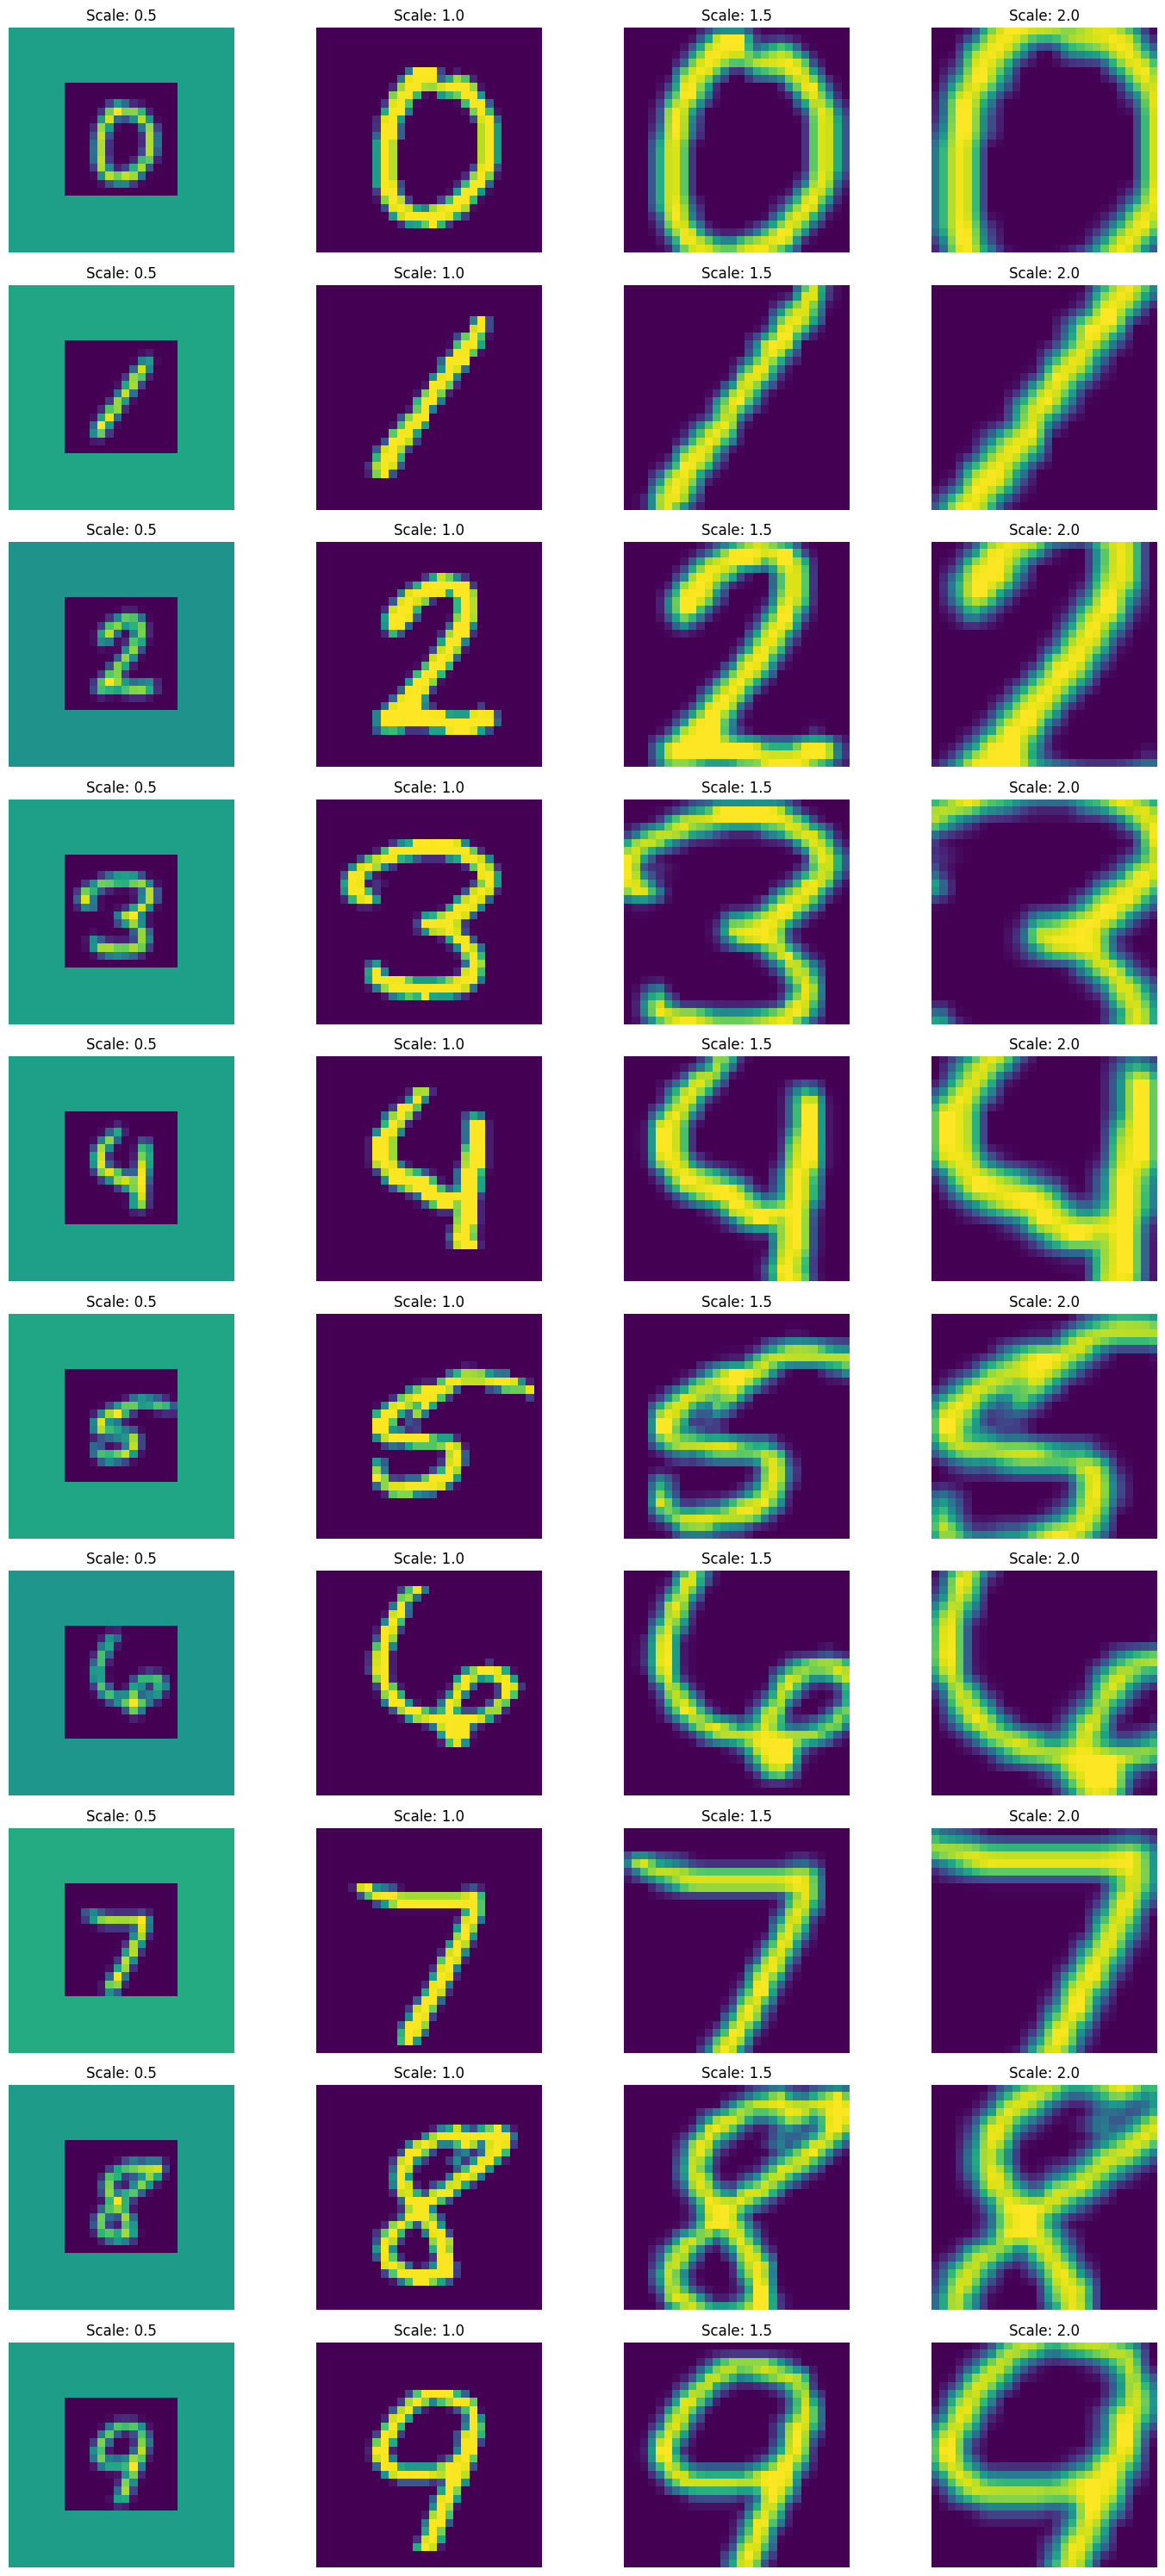

In [ ]:
def display_scaled_images(test_dataset, scaling_factors):
    class_images = {i: [] for i in range(10)}  # Dictionary to store images per class

    # Collect images per class
    for image, label in test_dataset:
        class_images[label].append(image)
        if len(class_images[label]) >= 10:  # Only need 10 images per class
            if all(len(class_images[i]) >= 10 for i in class_images):
                break

    # Plotting the images
    fig, axes = plt.subplots(10, len(scaling_factors), figsize=(15, 30))
    for class_id in range(10):
        for scale_idx, scale in enumerate(scaling_factors):
            # Take 10 images from each class and apply scaling
            images_to_plot = class_images[class_id][:10]
            scaled_images = [scale_image(img, scale) for img in images_to_plot]

            for i, img in enumerate(scaled_images):
                ax = axes[class_id, scale_idx]
                ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))  # Convert to HWC format for displaying
                ax.axis('off')
                if i == 0:
                    ax.set_title(f"Scale: {scale}")

    plt.tight_layout()
    plt.show()

# Call the function to display images
display_scaled_images(test_dataset, scaling_factors)

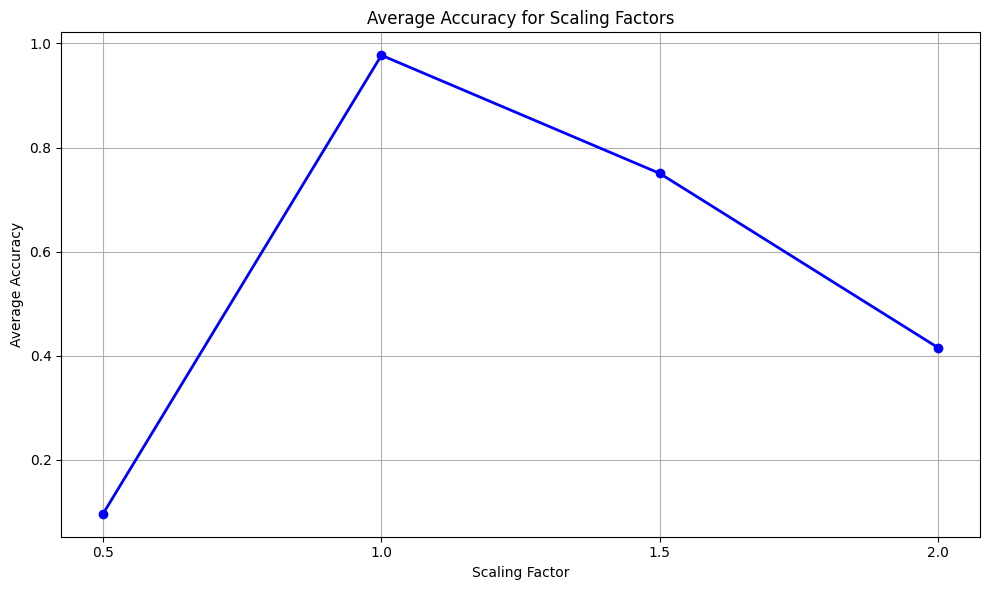

In [ ]:
def plot_scaling_accuracy(class_wise_scaling_results, scaling_factors):
    avg_accuracy = []

    # Calculate average accuracy
    for scale in scaling_factors:
        avg_accuracy.append(np.mean([class_wise_scaling_results[scale][i][f'accuracy_{scale}'] for i in range(10)]))

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(scaling_factors, avg_accuracy, marker='o', color='blue', linestyle='-', linewidth=2)

    # Labeling the plot
    plt.title('Average Accuracy for Scaling Factors')
    plt.xlabel('Scaling Factor')
    plt.ylabel('Average Accuracy')
    plt.xticks(scaling_factors)  #
    plt.grid(True)
    plt.tight_layout()
    plt.show()
plot_scaling_accuracy(class_wise_scaling_results, scaling_factors)

In [ ]:
import csv

# Data for the CSV
data = [
    ["Scaling", "Class 0", "Class 1", "Class 2", "Class 3", "Class 4", "Class 5", "Class 6", "Class 7", "Class 8", "Class 9", "Average accuracy", "Average Precision", "Average Recall", "Average F1-Score", "Average AUC"],
    ["0.5x", "0.0000", "0.0000", "0.3953", "0.4667", "0.0000", "0.0000", "0.0000", "0.0000", "0.0000", "0.0000", "0.0959", "0.1173", "0.0959", "0.0464", "0.6353"],
    ["1.0x", "0.9714", "1.0000", "0.9767", "0.9556", "0.9737", "0.9375", "1.0000", "0.9583", "1.0000", "1.0000", "0.9773", "0.9798", "0.9773", "0.9784", "0.9994"],
    ["1.5x", "0.8571", "0.9516", "0.7907", "0.6889", "0.9474", "0.8750", "0.7179", "0.7083", "0.2500", "0.7143", "0.7501", "0.7727", "0.7501", "0.7363", "0.9587"],
    ["2.0x", "0.5429", "0.8871", "0.5349", "0.0889", "0.6842", "0.5000", "0.3590", "0.3125", "0.1154", "0.1250", "0.4150", "0.4601", "0.4150", "0.3742", "0.8087"]
]

# File path for the CSV
file_path = 'scaling_factor_results.csv'

# Writing the data to the CSV file
with open(file_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    for row in data:
        writer.writerow(row)

print(f"CSV file '{file_path}' created successfully.")


CSV file 'scaling_factor_results.csv' created successfully.


In [ ]:
from google.colab import files
files.download('scaling_factor_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Sheering

In [ ]:
shear_values = [0.3, 0.5, 0.8, 1.0]
directions = ['x', 'y']

# Shearing function
def apply_shear(image, shear_factor, direction='x'):
    if direction == 'x':
        return TF.affine(image, angle=0, translate=[0, 0], scale=1.0, shear=[shear_factor * 180 / 3.1416, 0])
    elif direction == 'y':
        return TF.affine(image, angle=0, translate=[0, 0], scale=1.0, shear=[0, shear_factor * 180 / 3.1416])
    else:
        raise ValueError("Direction must be 'x' or 'y'.")

# Containers for results
class_wise_results = {
    shear: {
        direction: {
            i: {
                f"accuracy_{direction}_{shear}": 0,
                f"precision_{direction}_{shear}": 0,
                f"recall_{direction}_{shear}": 0,
                f"f1_score_{direction}_{shear}": 0,
                f"auc_{direction}_{shear}": 0
            } for i in range(10)
        } for direction in directions
    } for shear in shear_values
}

# Run shearing experiments
for shear in shear_values:
    for direction in directions:
        sheared_images = []
        sheared_labels = []

        for image, label in test_dataset:
            sheared_image = apply_shear(image, shear, direction)
            sheared_images.append(sheared_image)
            sheared_labels.append(label)

        sheared_loader = DataLoader(list(zip(sheared_images, sheared_labels)), batch_size=64)

        all_preds = []
        all_targets = []
        all_probs = []

        with torch.no_grad():
            for images, labels in sheared_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = loaded_model(images)

                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(labels.cpu().numpy())
                probs = torch.nn.functional.softmax(outputs, dim=1)
                all_probs.extend(probs.cpu().numpy())

        # Metrics
        for i in range(10):
            class_idx = np.where(np.array(all_targets) == i)[0]
            if len(class_idx) > 0:
                correct = np.sum(np.array(all_preds)[class_idx] == i)
                accuracy = correct / len(class_idx)

                precision = precision_score(all_targets, all_preds, labels=[i], average='weighted', zero_division=0)
                recall = recall_score(all_targets, all_preds, labels=[i], average='weighted', zero_division=0)
                f1 = f1_score(all_targets, all_preds, labels=[i], average='weighted', zero_division=0)

                try:
                    auc = roc_auc_score(all_targets, all_probs, multi_class='ovr', average='weighted')
                except:
                    auc = float('nan')

                class_wise_results[shear][direction][i][f"accuracy_{direction}_{shear}"] += accuracy
                class_wise_results[shear][direction][i][f"precision_{direction}_{shear}"] += precision
                class_wise_results[shear][direction][i][f"recall_{direction}_{shear}"] += recall
                class_wise_results[shear][direction][i][f"f1_score_{direction}_{shear}"] += f1
                class_wise_results[shear][direction][i][f"auc_{direction}_{shear}"] += auc

# Display results
for shear in shear_values:
    for direction in directions:
        print(f"\nResults for shearing in {direction}-axis with shear = {shear}")
        for i in range(10):
            print(f"\nClass {i}:")
            print(f"  Accuracy: {class_wise_results[shear][direction][i][f'accuracy_{direction}_{shear}']:.4f}")
            print(f"  Precision: {class_wise_results[shear][direction][i][f'precision_{direction}_{shear}']:.4f}")
            print(f"  Recall: {class_wise_results[shear][direction][i][f'recall_{direction}_{shear}']:.4f}")
            print(f"  F1 Score: {class_wise_results[shear][direction][i][f'f1_score_{direction}_{shear}']:.4f}")
            print(f"  AUC: {class_wise_results[shear][direction][i][f'auc_{direction}_{shear}']:.4f}")



Results for shearing in x-axis with shear = 0.3

Class 0:
  Accuracy: 0.9714
  Precision: 0.9444
  Recall: 0.9714
  F1 Score: 0.9577
  AUC: 0.9964

Class 1:
  Accuracy: 0.9839
  Precision: 0.9839
  Recall: 0.9839
  F1 Score: 0.9839
  AUC: 0.9964

Class 2:
  Accuracy: 0.9535
  Precision: 0.8039
  Recall: 0.9535
  F1 Score: 0.8723
  AUC: 0.9964

Class 3:
  Accuracy: 0.9333
  Precision: 0.9130
  Recall: 0.9333
  F1 Score: 0.9231
  AUC: 0.9964

Class 4:
  Accuracy: 0.9474
  Precision: 1.0000
  Recall: 0.9474
  F1 Score: 0.9730
  AUC: 0.9964

Class 5:
  Accuracy: 0.9375
  Precision: 0.8333
  Recall: 0.9375
  F1 Score: 0.8824
  AUC: 0.9964

Class 6:
  Accuracy: 0.9744
  Precision: 0.9744
  Recall: 0.9744
  F1 Score: 0.9744
  AUC: 0.9964

Class 7:
  Accuracy: 0.7500
  Precision: 0.9474
  Recall: 0.7500
  F1 Score: 0.8372
  AUC: 0.9964

Class 8:
  Accuracy: 0.9423
  Precision: 0.9608
  Recall: 0.9423
  F1 Score: 0.9515
  AUC: 0.9964

Class 9:
  Accuracy: 0.9107
  Precision: 0.9273
  Recall: 0

In [ ]:
# Calculate and print average metrics for each shear and direction
for shear in shear_values:
    for direction in directions:
        avg_accuracy = np.mean([class_wise_results[shear][direction][i][f"accuracy_{direction}_{shear}"] for i in range(10)])
        avg_precision = np.mean([class_wise_results[shear][direction][i][f"precision_{direction}_{shear}"] for i in range(10)])
        avg_recall = np.mean([class_wise_results[shear][direction][i][f"recall_{direction}_{shear}"] for i in range(10)])
        avg_f1 = np.mean([class_wise_results[shear][direction][i][f"f1_score_{direction}_{shear}"] for i in range(10)])
        avg_auc = np.mean([class_wise_results[shear][direction][i][f"auc_{direction}_{shear}"] for i in range(10)])

        print(f"\nAverage Metrics for shear = {shear} in {direction}-axis:")
        print(f"  Average Accuracy: {avg_accuracy:.4f}")
        print(f"  Average Precision: {avg_precision:.4f}")
        print(f"  Average Recall: {avg_recall:.4f}")
        print(f"  Average F1 Score: {avg_f1:.4f}")
        print(f"  Average AUC: {avg_auc:.4f}")



Average Metrics for shear = 0.3 in x-axis:
  Average Accuracy: 0.9304
  Average Precision: 0.9288
  Average Recall: 0.9304
  Average F1 Score: 0.9274
  Average AUC: 0.9964

Average Metrics for shear = 0.3 in y-axis:
  Average Accuracy: 0.9414
  Average Precision: 0.9441
  Average Recall: 0.9414
  Average F1 Score: 0.9414
  Average AUC: 0.9984

Average Metrics for shear = 0.5 in x-axis:
  Average Accuracy: 0.8352
  Average Precision: 0.8492
  Average Recall: 0.8352
  Average F1 Score: 0.8264
  Average AUC: 0.9870

Average Metrics for shear = 0.5 in y-axis:
  Average Accuracy: 0.7981
  Average Precision: 0.8332
  Average Recall: 0.7981
  Average F1 Score: 0.8009
  Average AUC: 0.9824

Average Metrics for shear = 0.8 in x-axis:
  Average Accuracy: 0.5427
  Average Precision: 0.6711
  Average Recall: 0.5427
  Average F1 Score: 0.5041
  Average AUC: 0.8688

Average Metrics for shear = 0.8 in y-axis:
  Average Accuracy: 0.2568
  Average Precision: 0.2834
  Average Recall: 0.2568
  Average F

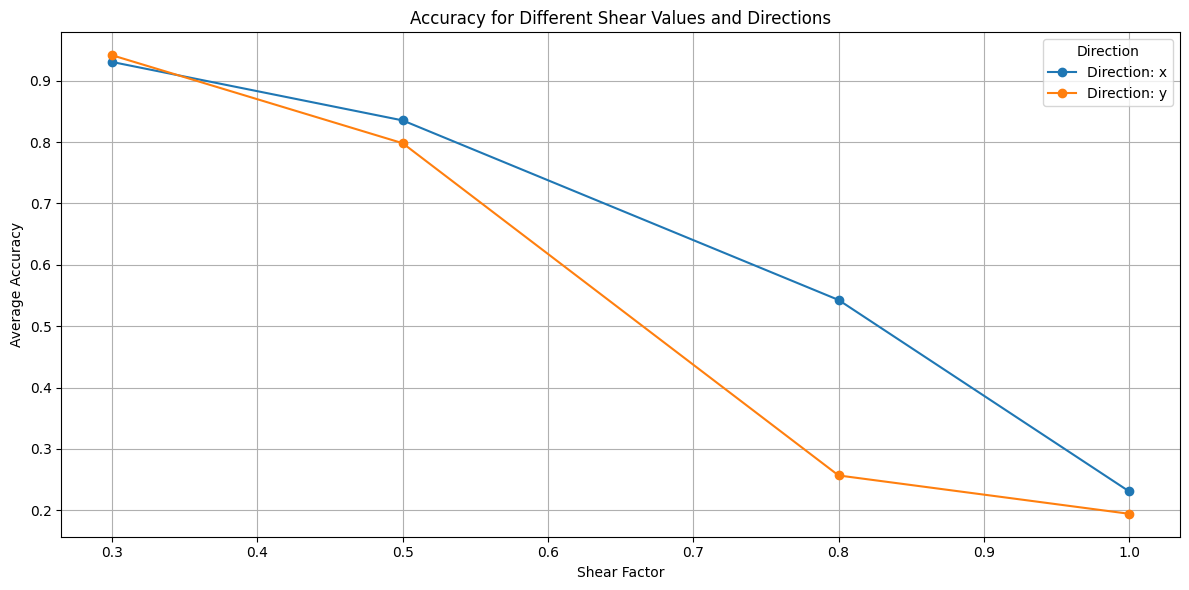

In [ ]:
def plot_shear_accuracy(class_wise_results, shear_values, directions):
    plt.figure(figsize=(12, 6))

    # Loop through directions and shear values to plot accuracy
    for direction in directions:
        avg_accuracy = []

        # Calculate average accuracy for each shear value in the current direction
        for shear in shear_values:
            avg_accuracy.append(np.mean([class_wise_results[shear][direction][i][f'accuracy_{direction}_{shear}'] for i in range(10)]))

        plt.plot(shear_values, avg_accuracy, marker='o', label=f'Direction: {direction}')

    plt.title('Accuracy for Different Shear Values and Directions')
    plt.xlabel('Shear Factor')
    plt.ylabel('Average Accuracy')
    plt.legend(title="Direction")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_shear_accuracy(class_wise_results, shear_values, directions)

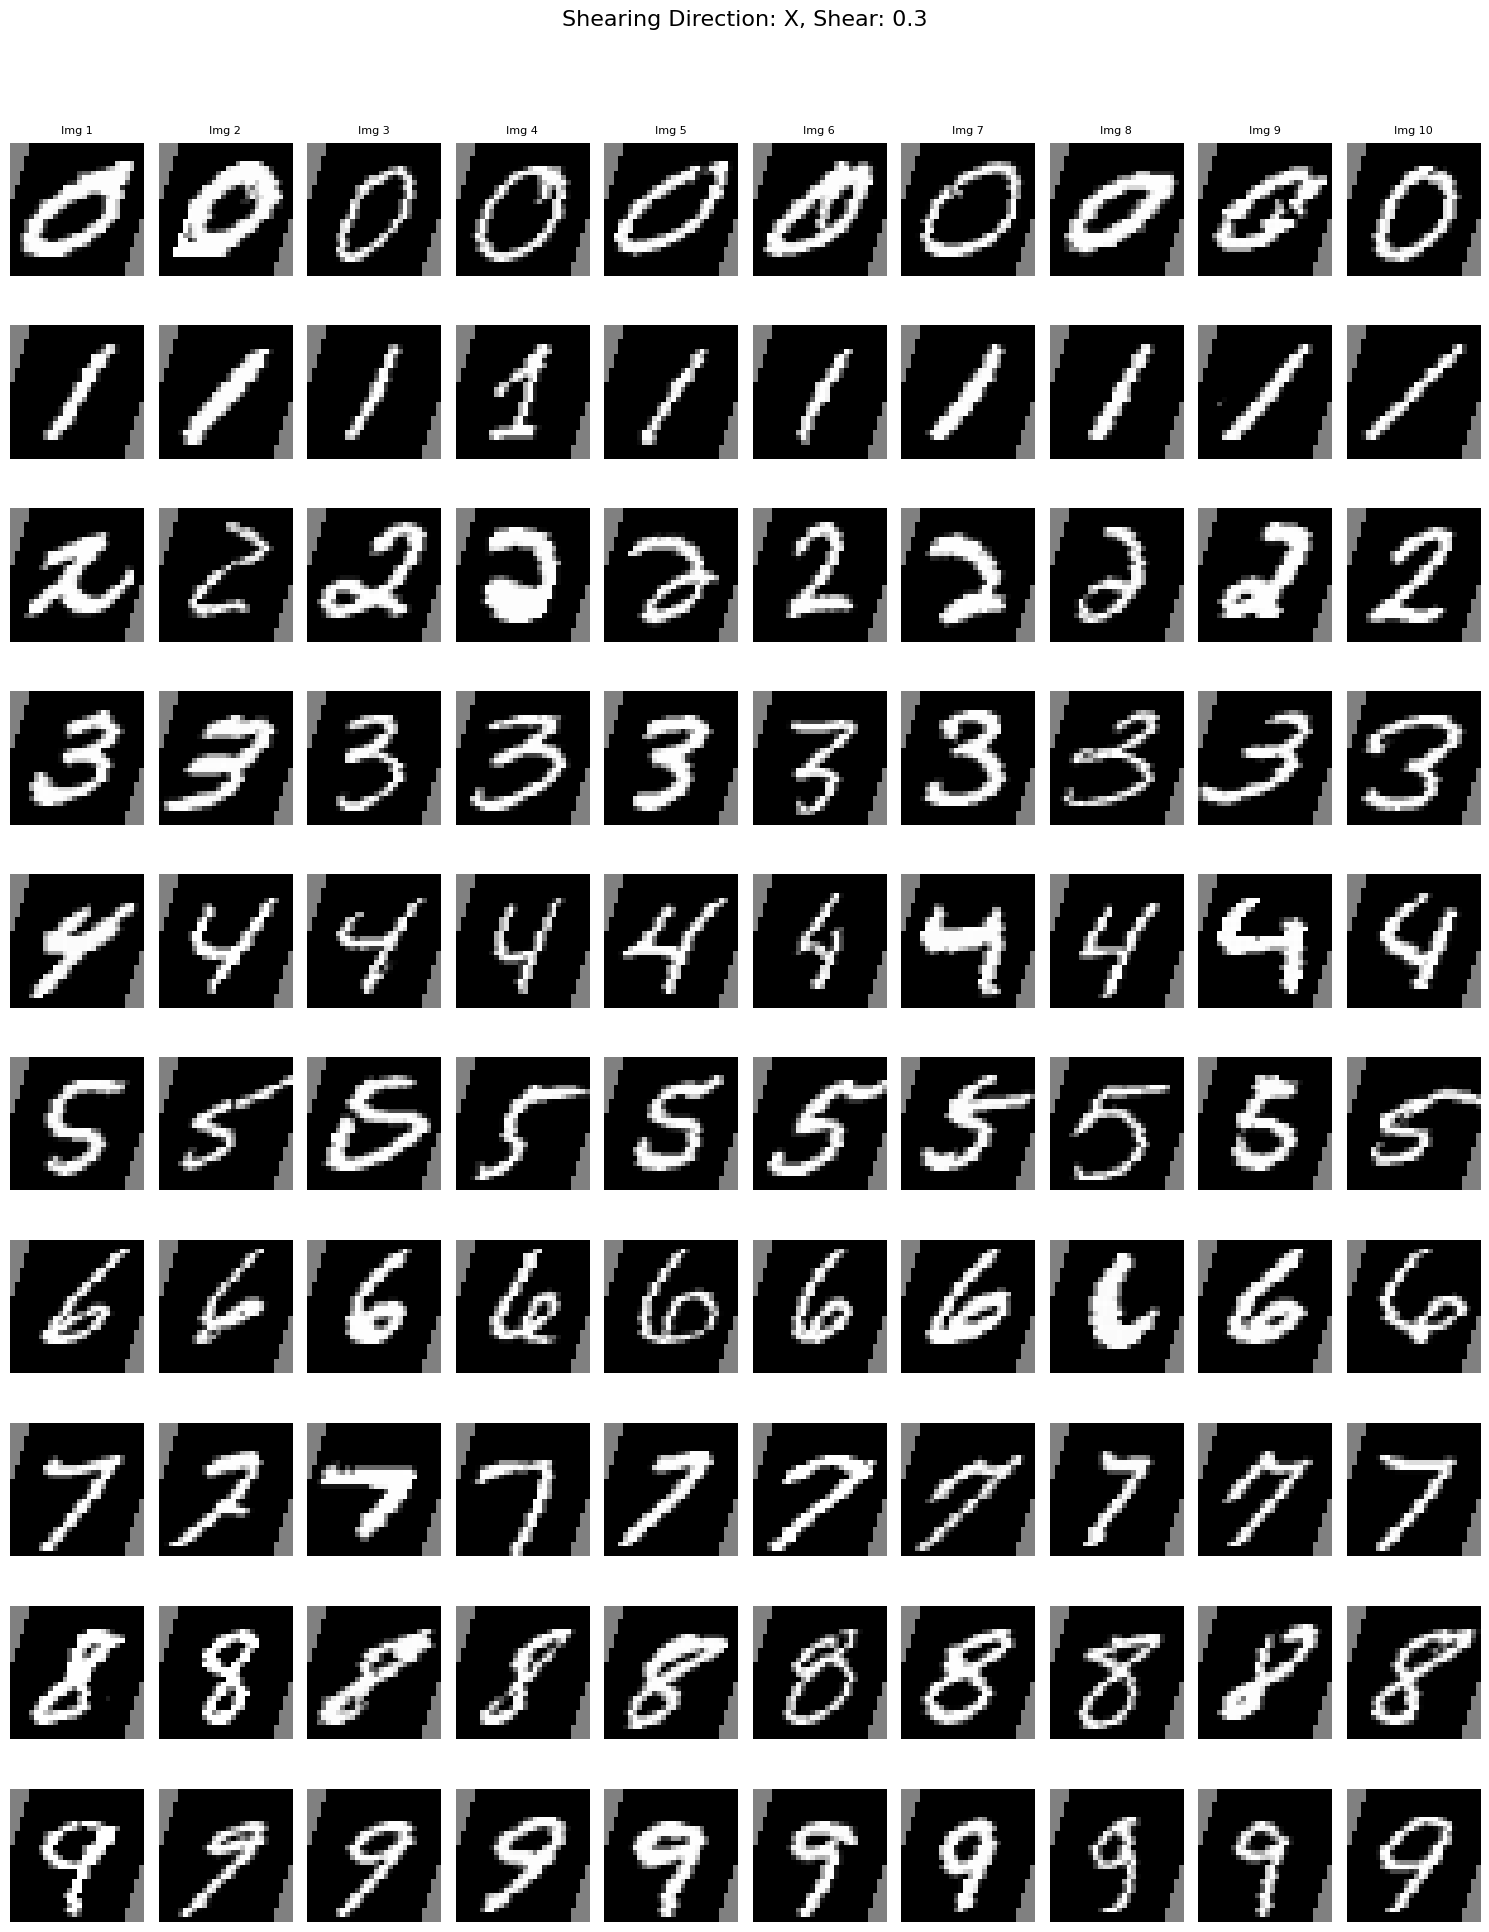

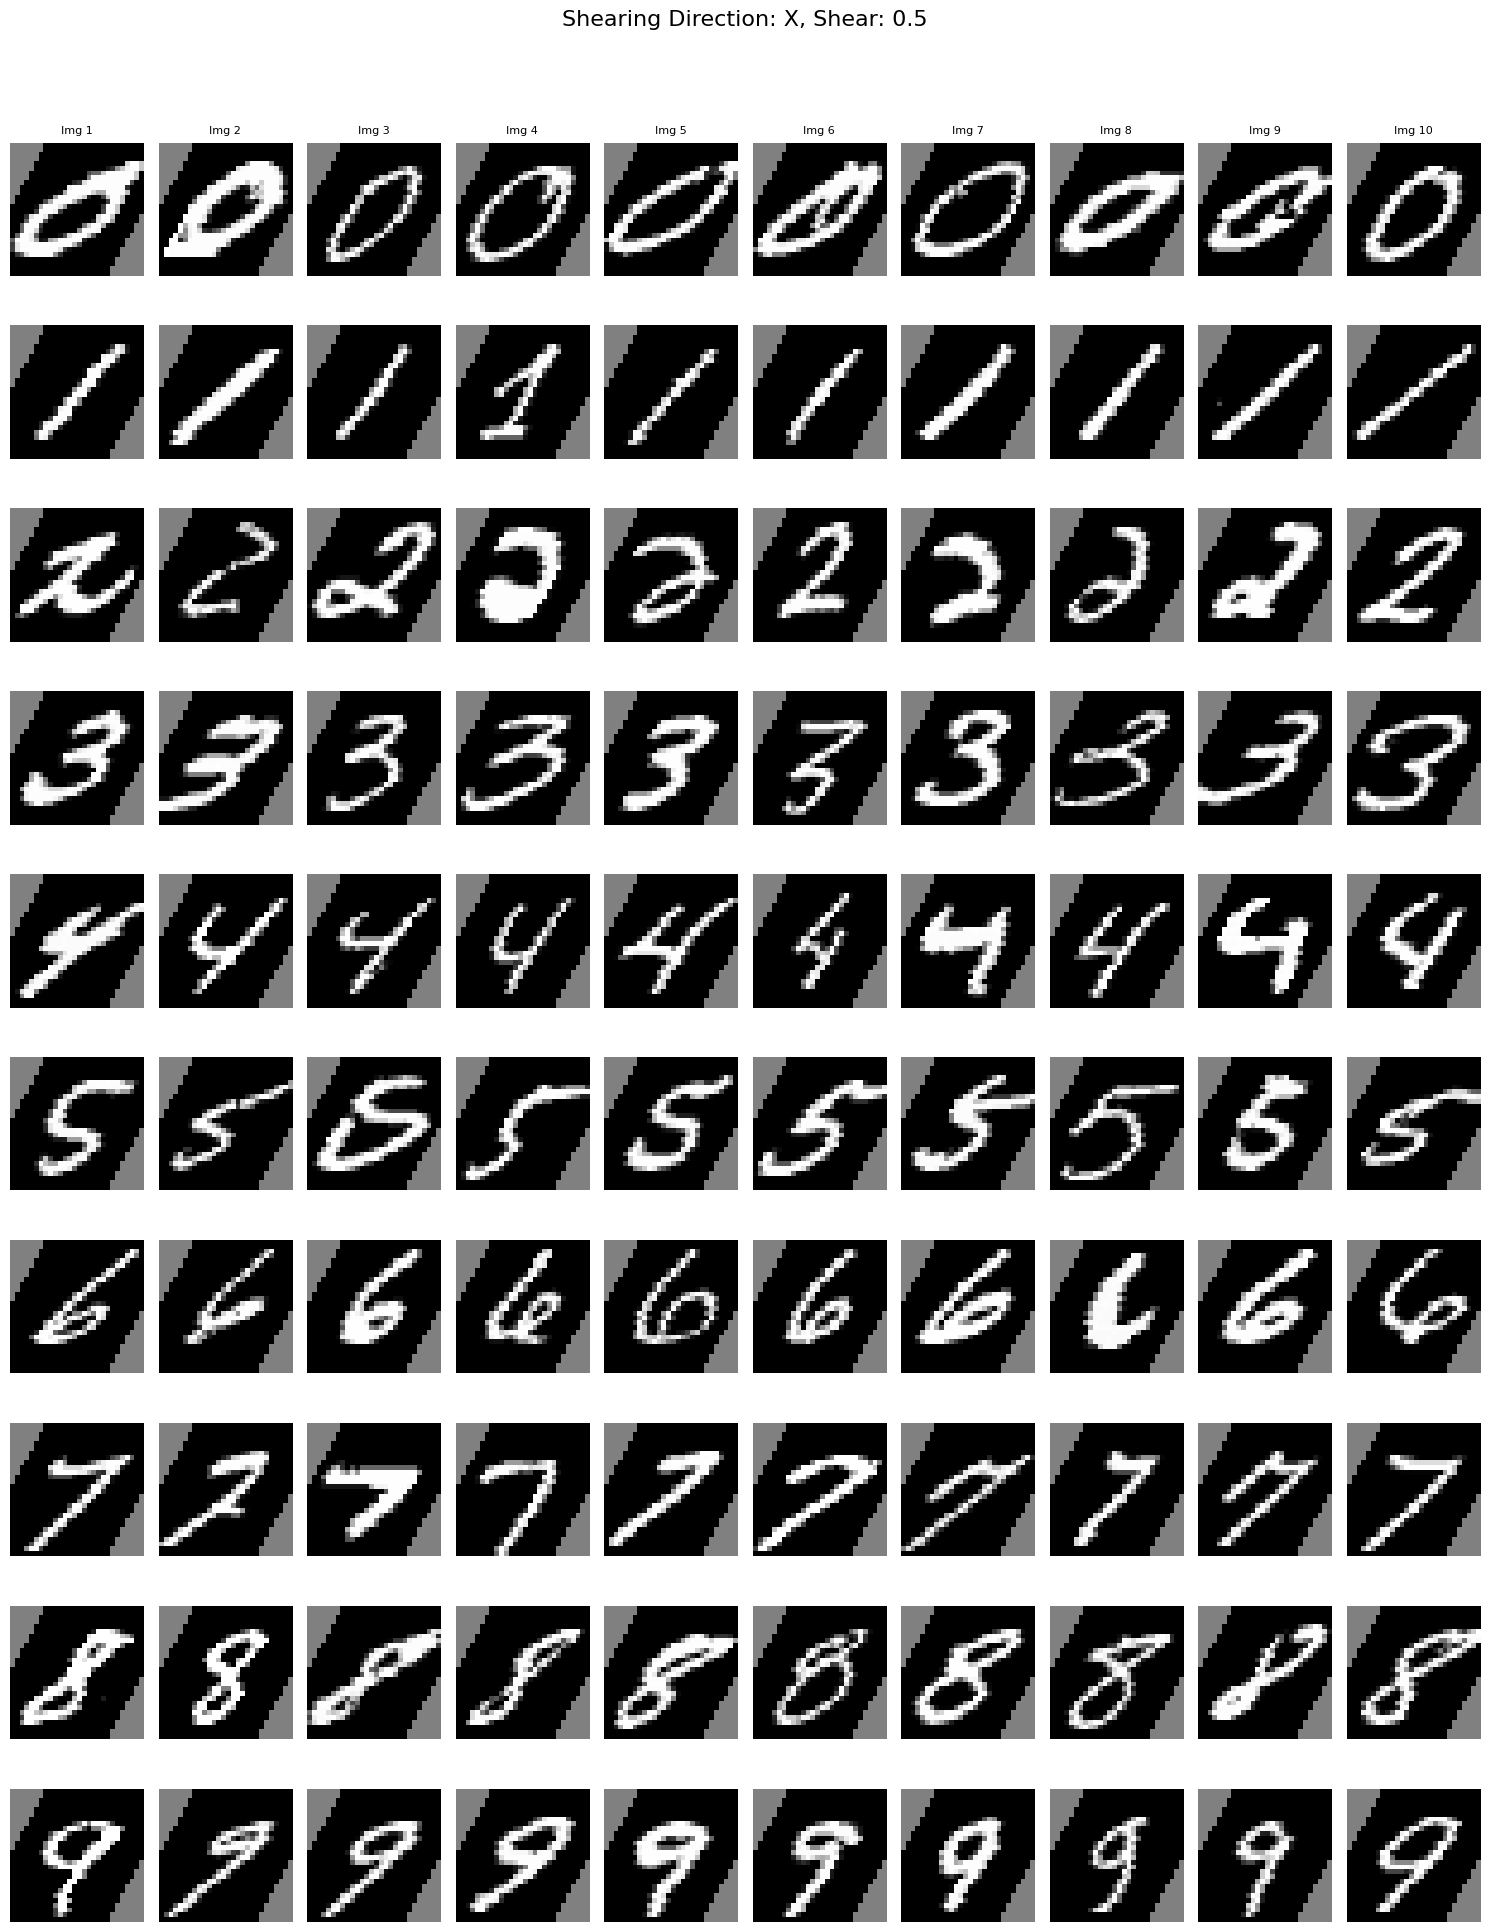

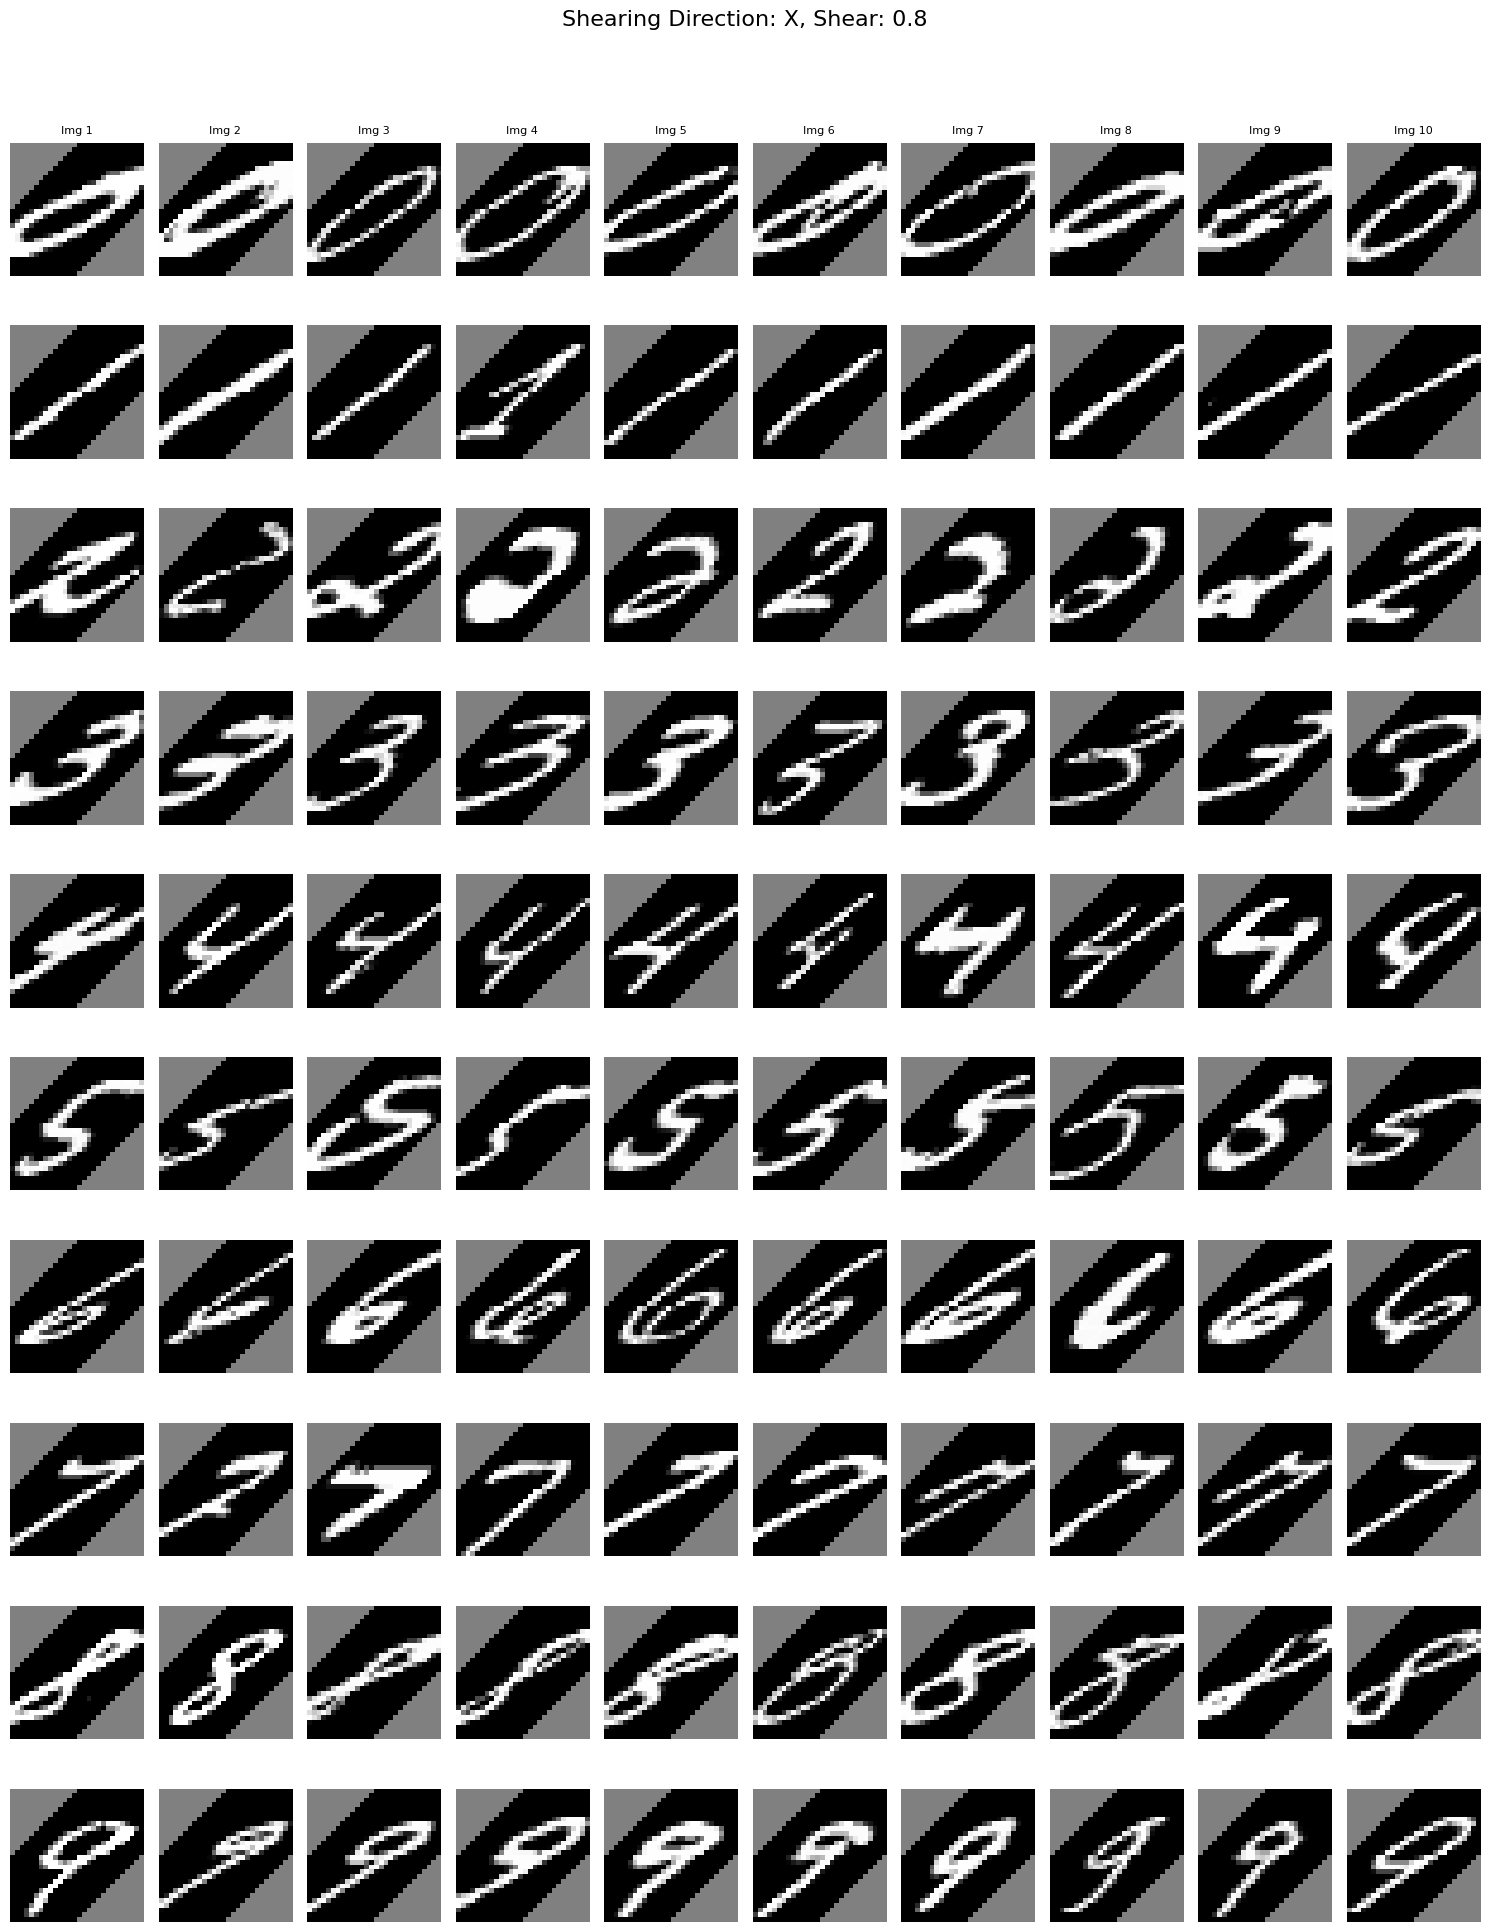

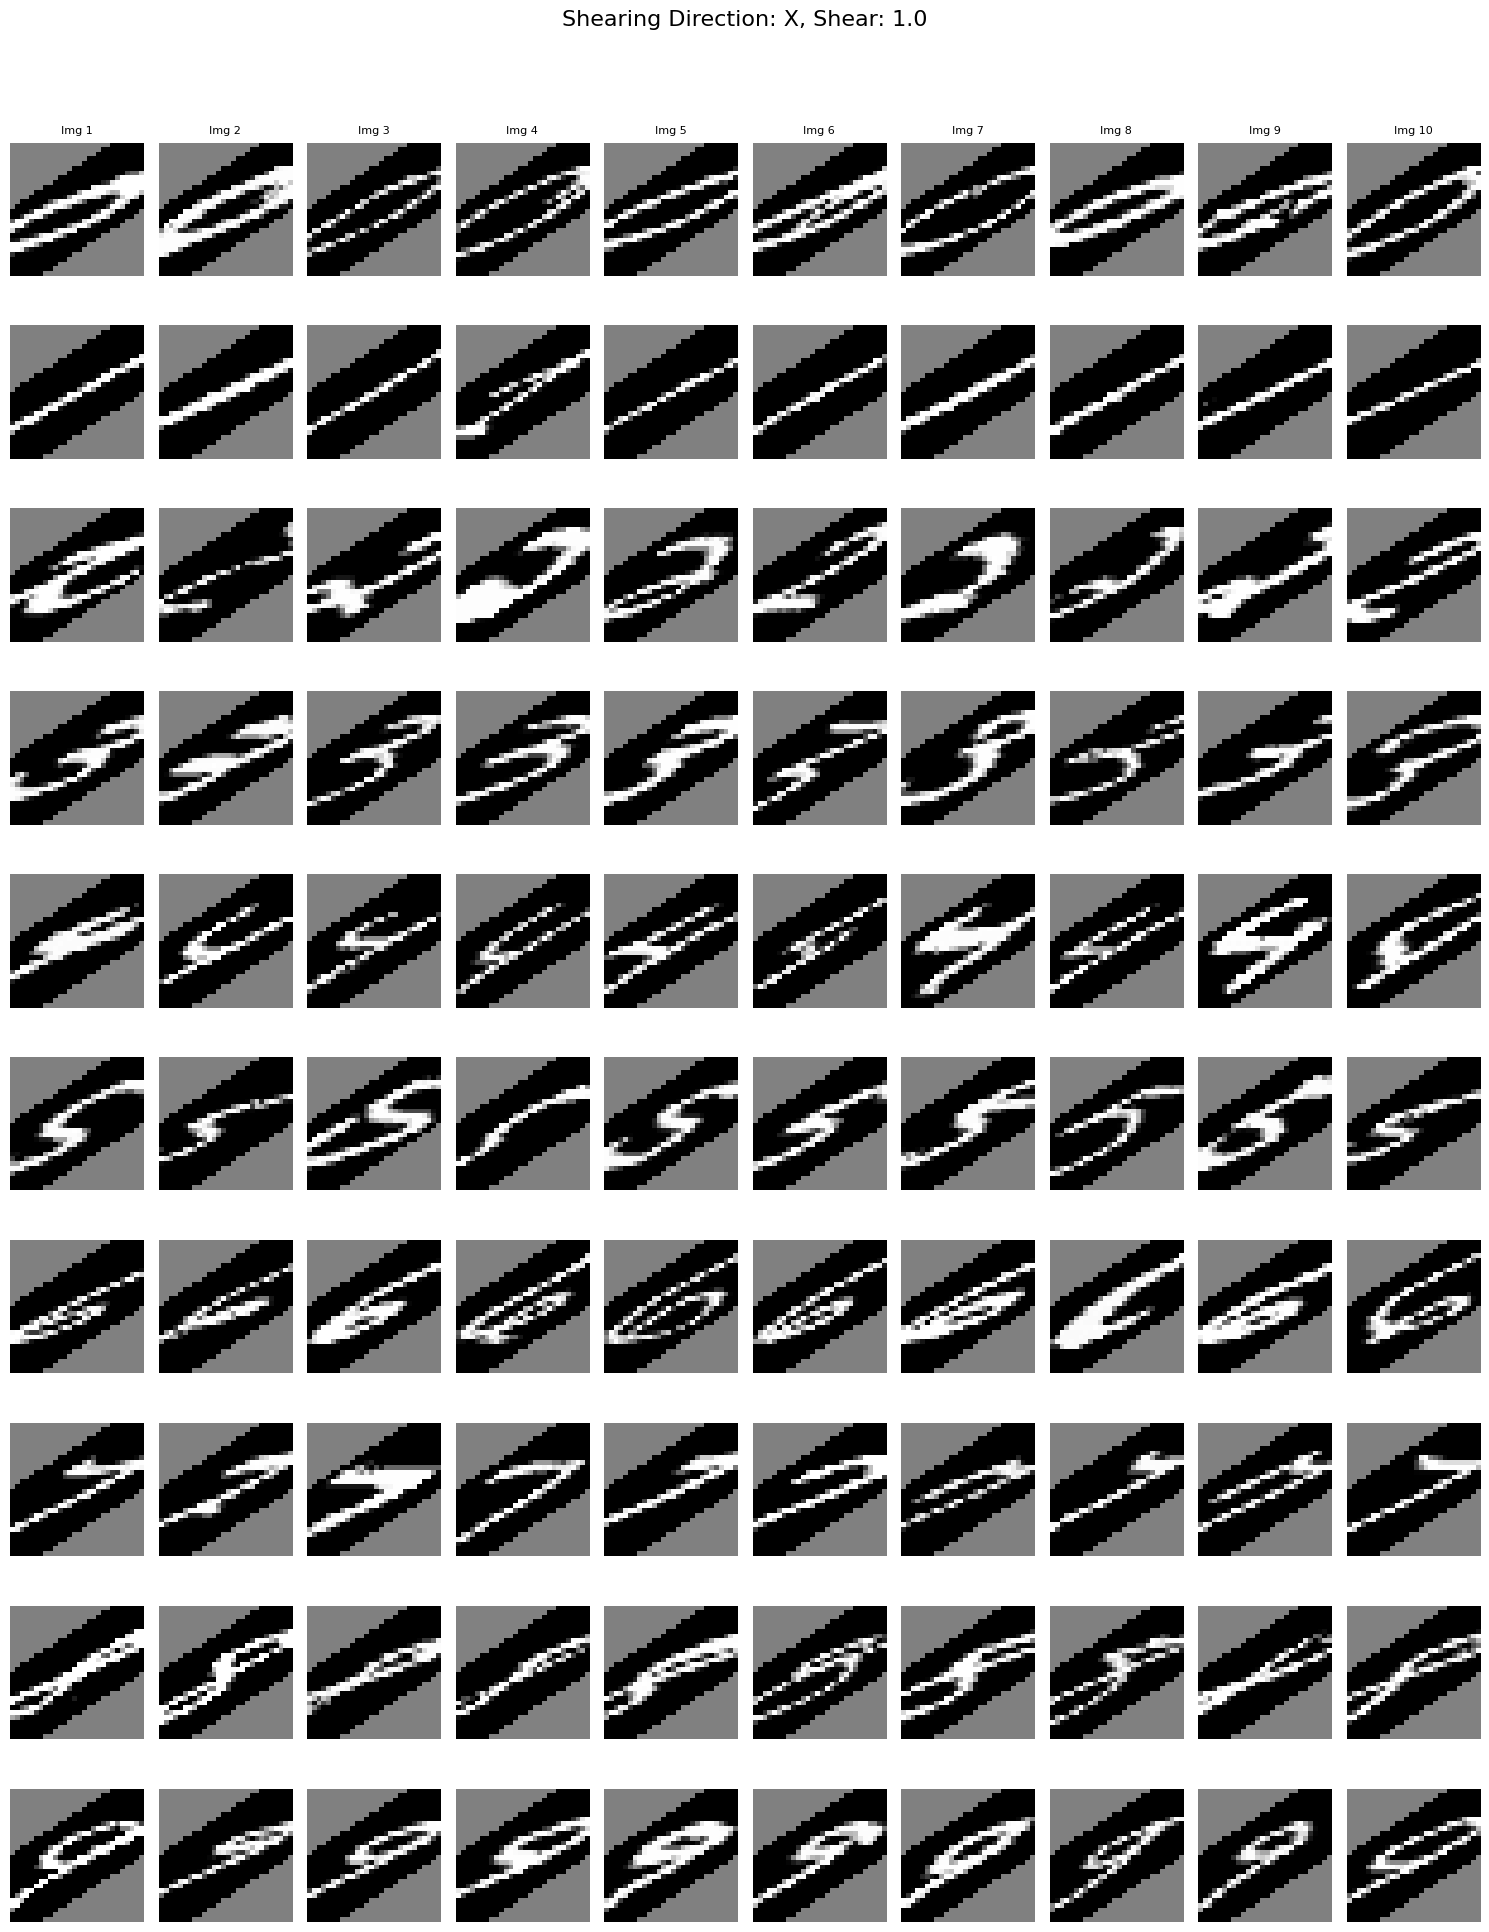

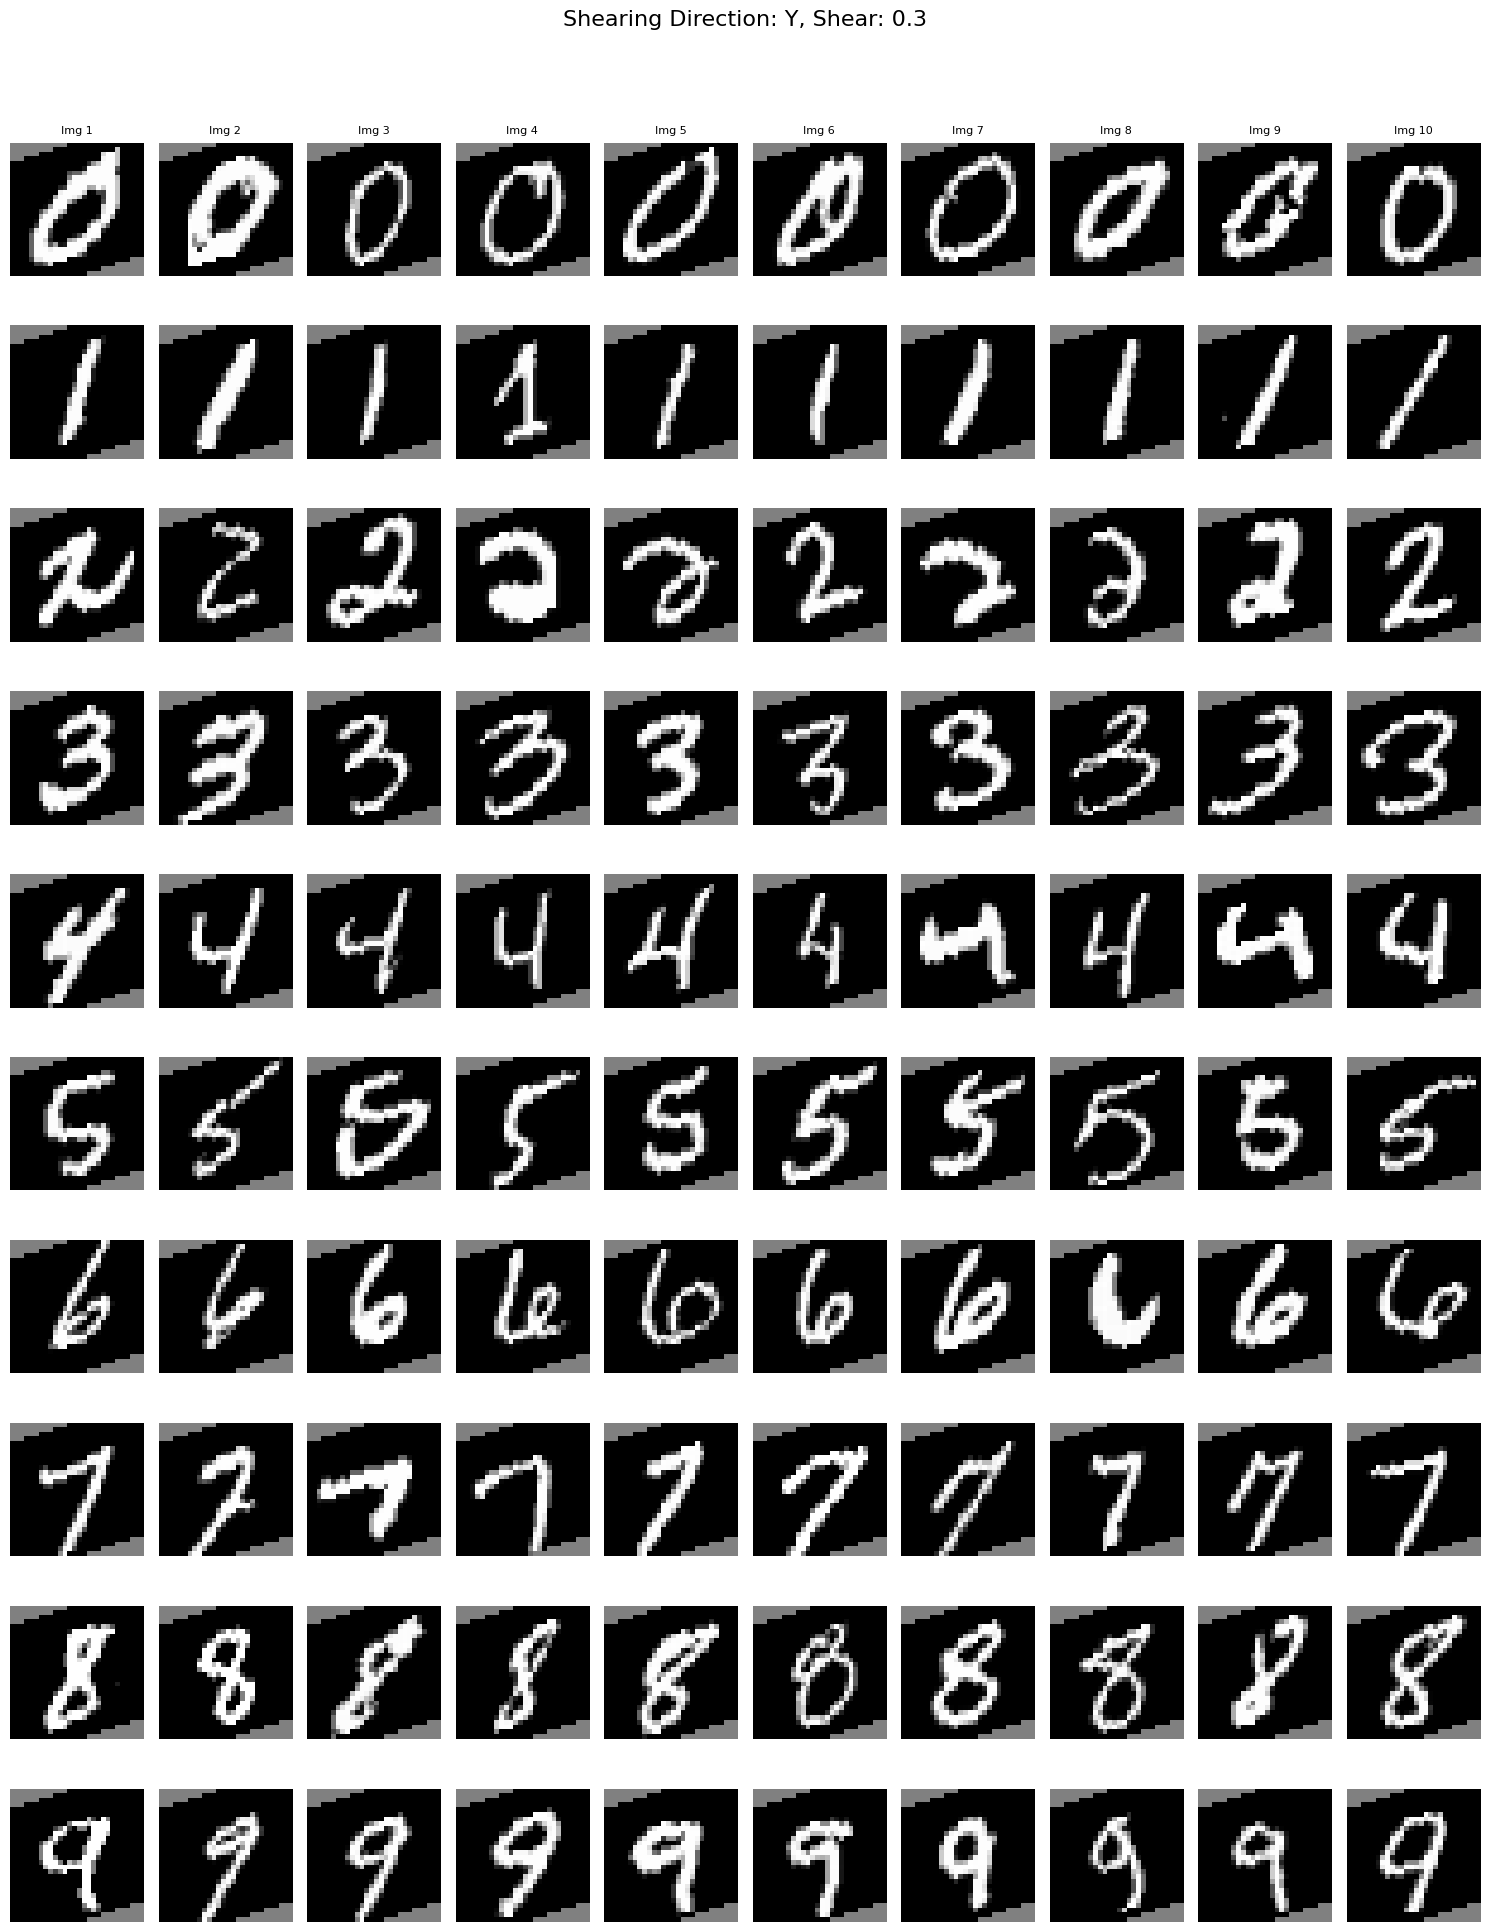

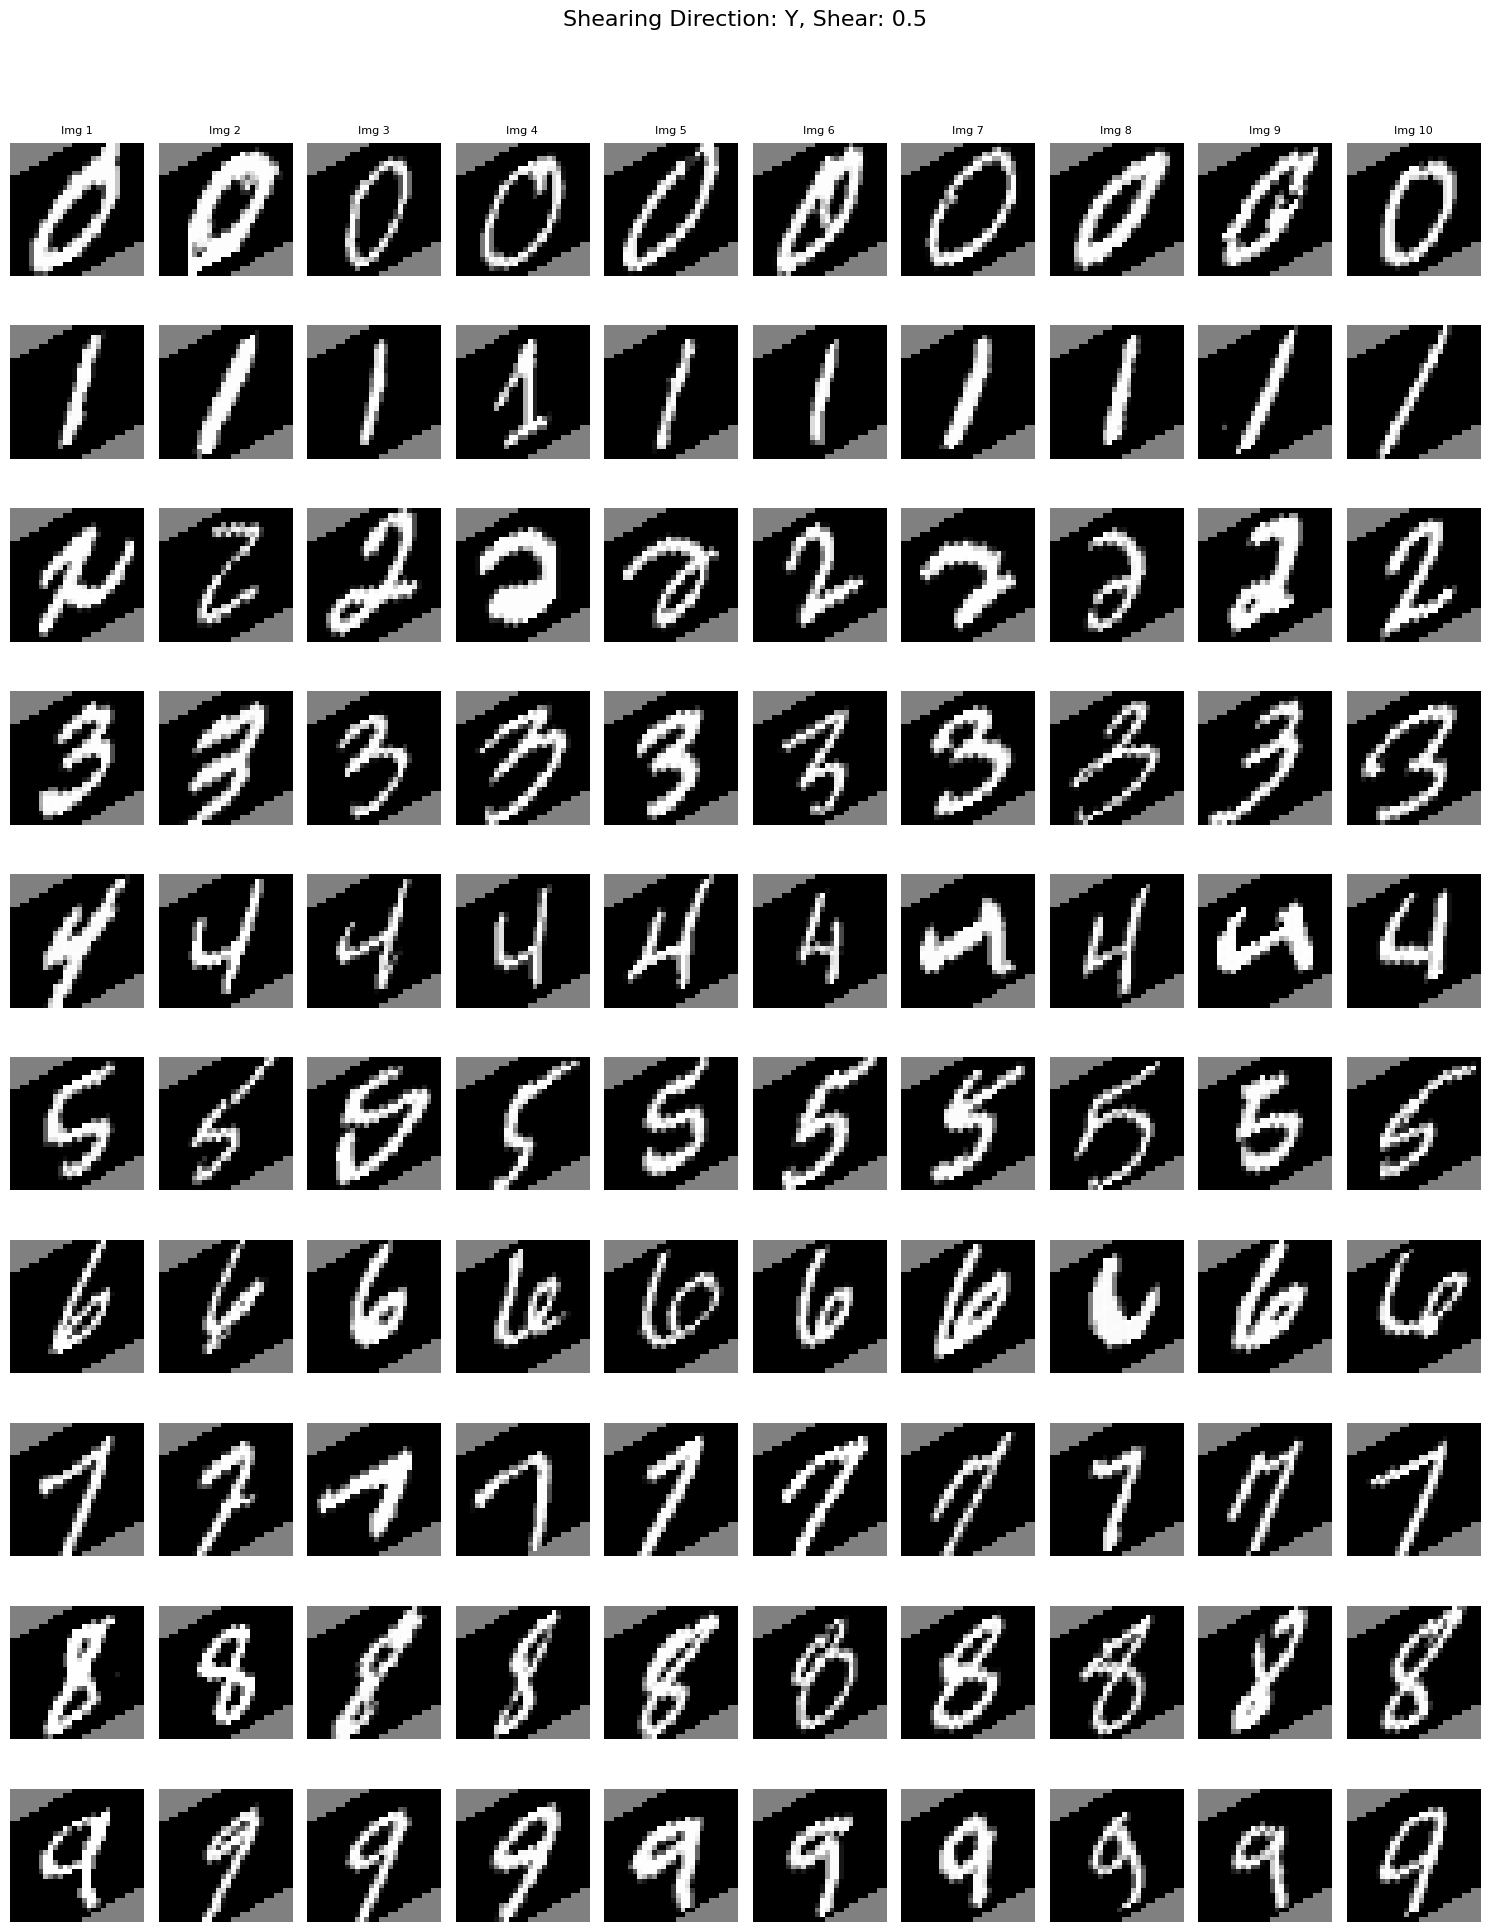

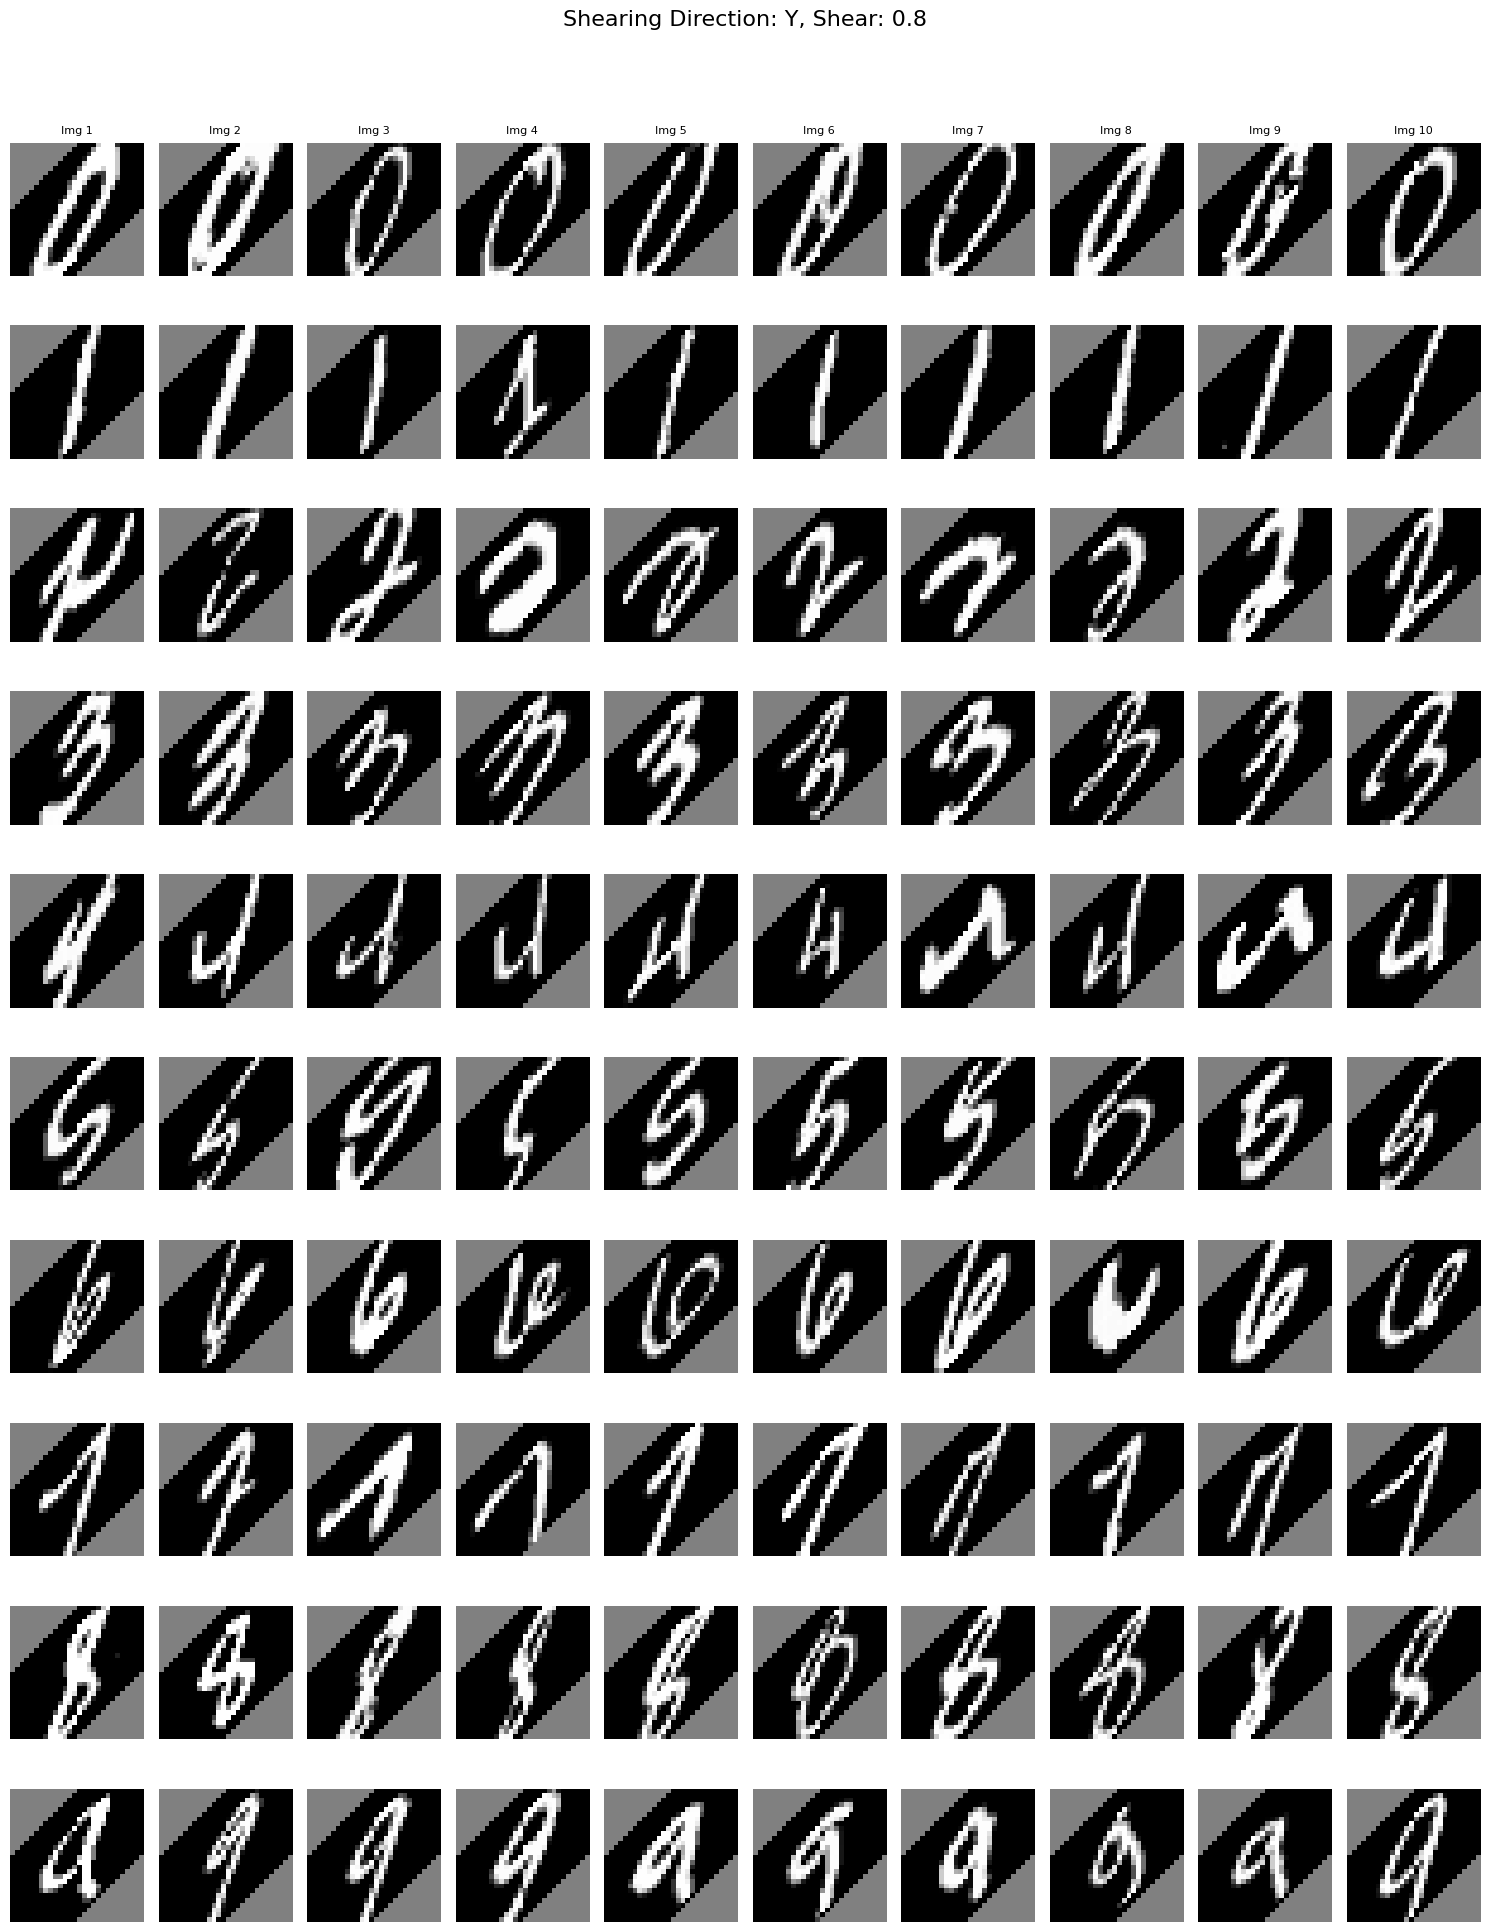

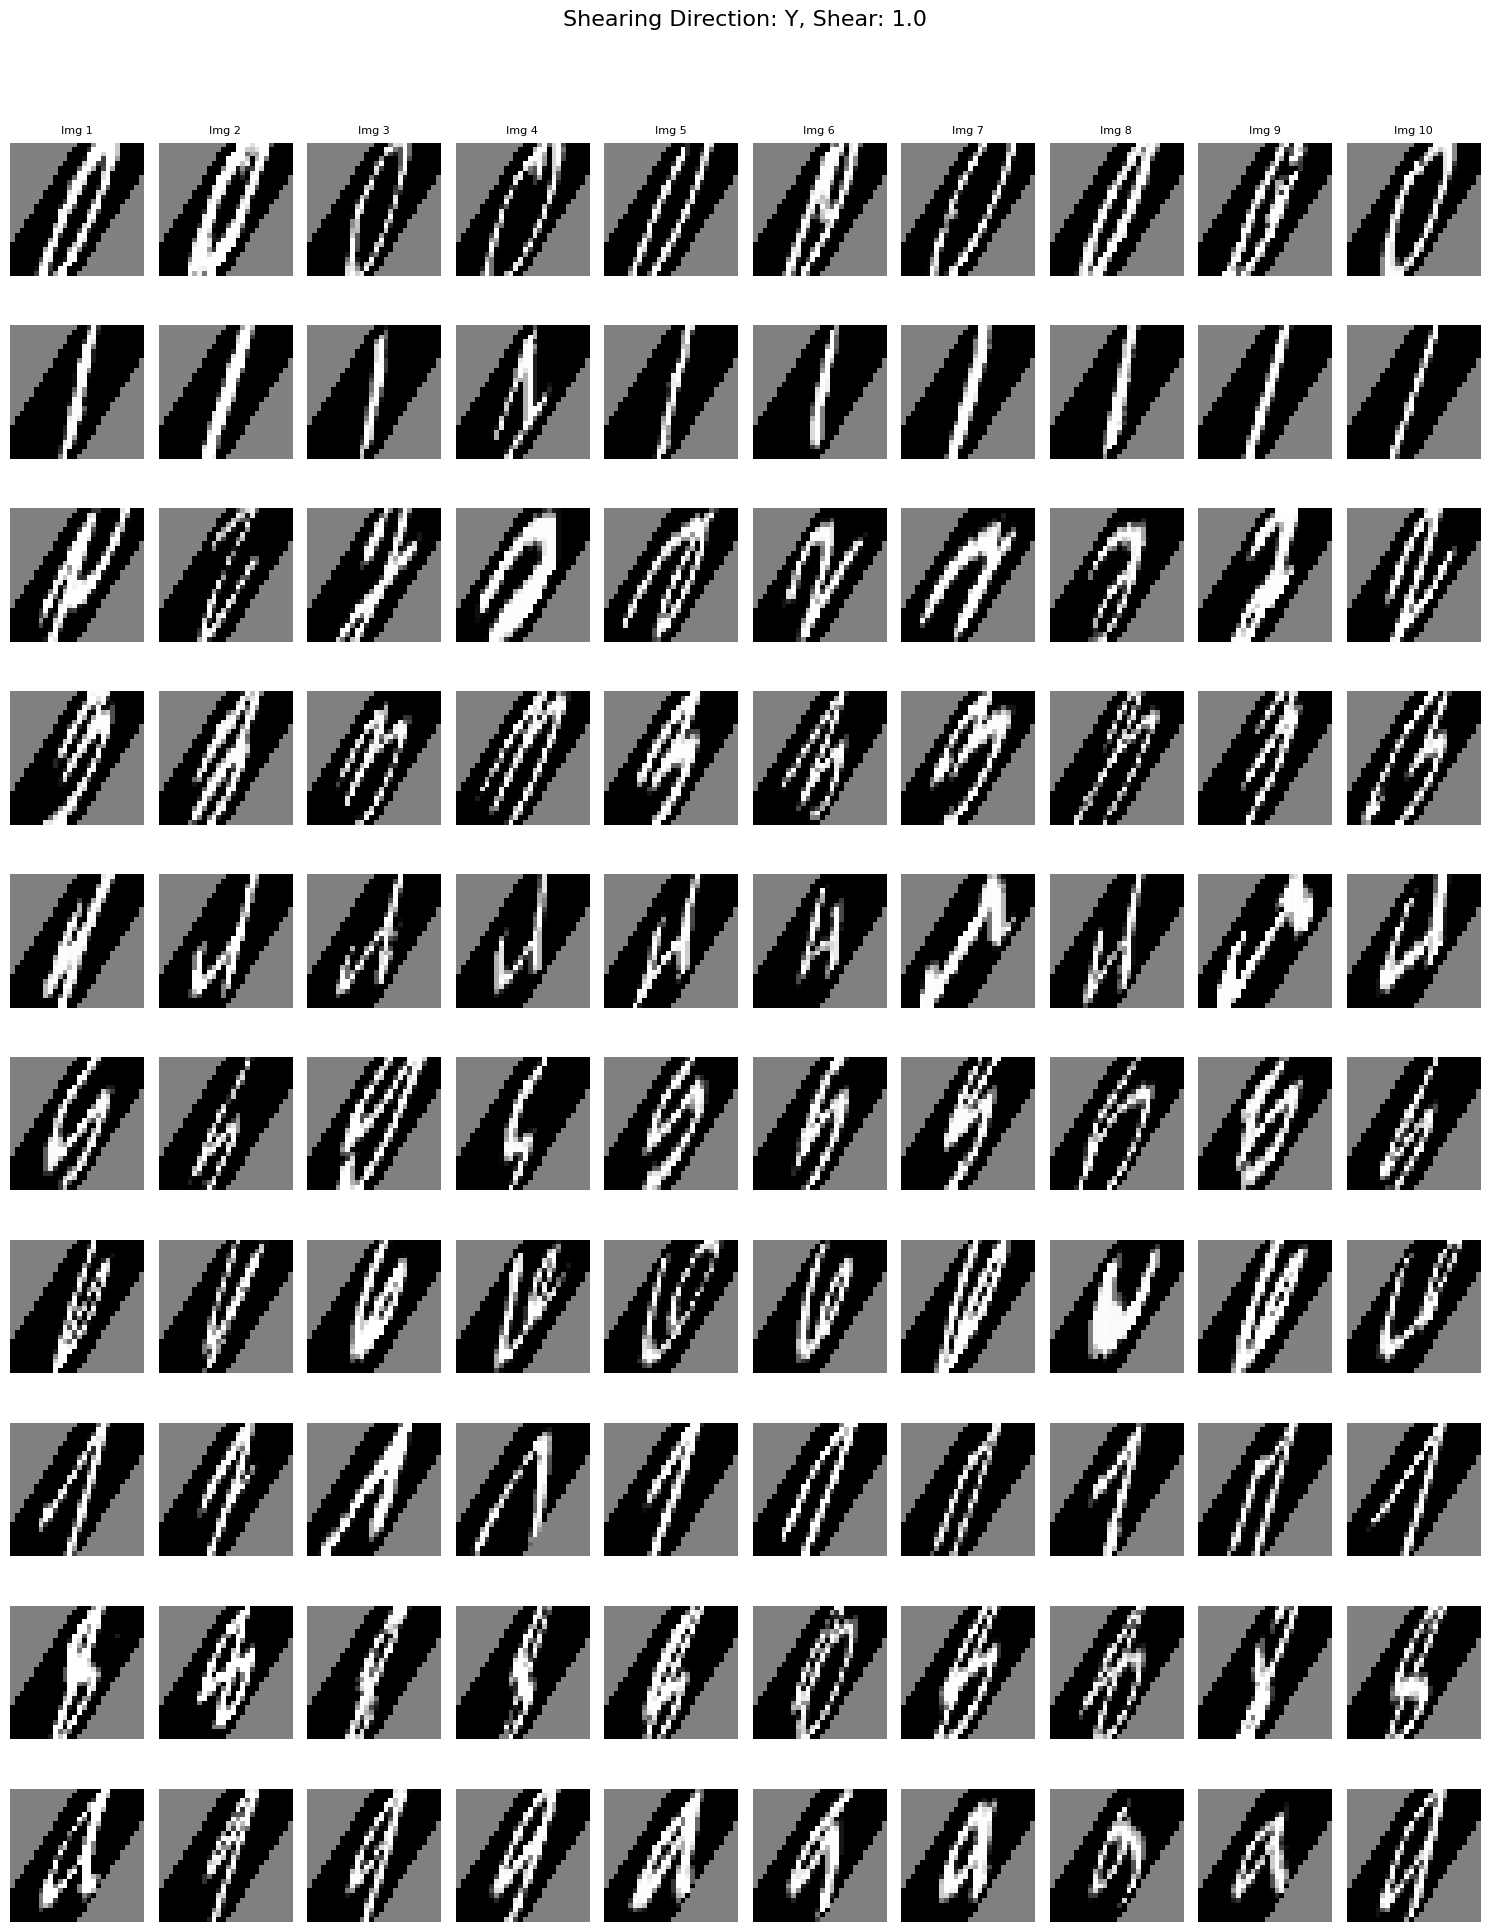

In [ ]:
# Shearing values and directions
shear_values = [0.3, 0.5, 0.8, 1.0]
directions = ['x', 'y']

# Shearing function
def apply_shear(image, shear_factor, direction='x'):
    if direction == 'x':
        return TF.affine(image, angle=0, translate=[0, 0], scale=1.0,
                         shear=[shear_factor * 180 / 3.1416, 0])
    elif direction == 'y':
        return TF.affine(image, angle=0, translate=[0, 0], scale=1.0,
                         shear=[0, shear_factor * 180 / 3.1416])
    else:
        raise ValueError("Direction must be 'x' or 'y'.")

# Display sheared images
def display_sheared_images(test_dataset, shear_values, directions):
    class_images = {i: [] for i in range(10)}

    # Collect 10 images per class
    for image, label in test_dataset:
        if len(class_images[label]) < 10:
            class_images[label].append(image)
        if all(len(class_images[i]) == 10 for i in range(10)):
            break

    for direction in directions:
        for shear in shear_values:
            fig, axes = plt.subplots(10, 10, figsize=(15, 20))
            fig.suptitle(f'Shearing Direction: {direction.upper()}, Shear: {shear}', fontsize=16)

            for class_id in range(10):
                sheared_imgs = [apply_shear(img, shear, direction) for img in class_images[class_id]]
                for i, img in enumerate(sheared_imgs):
                    ax = axes[class_id, i]
                    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)), cmap='gray')
                    ax.axis('off')
                    if class_id == 0:
                        ax.set_title(f'Img {i+1}', fontsize=8)
            plt.tight_layout()
            plt.subplots_adjust(top=0.93)
            plt.show()

# Call to display
display_sheared_images(test_dataset, shear_values, directions)

In [ ]:
import csv

# Data for shear results (including class and average metrics)
shear_data = [
    ["Sheering", "Axis", "Class 0", "Class 1", "Class 2", "Class 3", "Class 4", "Class 5", "Class 6", "Class 7", "Class 8", "Class 9", "Average accuracy", "Average Precision", "Average Recall", "Average F1- Score", "Average AUC"],
    [0.3, "x-axis", 0.9714, 0.9839, 0.9535, 0.9333, 0.9474, 0.9375, 0.9744, 0.7500, 0.9423, 0.9107, 0.9304, 0.9288, 0.9304, 0.9274, 0.9964],
    [0.3, "y-axis", 1.0000, 1.0000, 0.9070, 0.8667, 0.9737, 0.9375, 0.9487, 0.8750, 0.9231, 0.9821, 0.9414, 0.9441, 0.9414, 0.9414, 0.9984],
    [0.5, "x-axis", 0.9429, 0.9839, 0.8837, 0.8667, 0.8947, 0.9375, 0.8462, 0.4583, 0.7885, 0.7500, 0.8352, 0.8492, 0.8352, 0.8264, 0.9870],
    [0.5, "y-axis", 0.9429, 1.0000, 0.8140, 0.7111, 0.8947, 0.6562, 0.8718, 0.5625, 0.6346, 0.8929, 0.7981, 0.8332, 0.7981, 0.8009, 0.9824],
    [0.8, "x-axis", 0.5429, 0.9355, 0.8372, 0.6222, 0.7632, 0.8438, 0.5128, 0.0208, 0.1346, 0.2143, 0.5427, 0.6711, 0.5427, 0.5041, 0.8688],
    [0.8, "y-axis", 0.3143, 0.9839, 0.3721, 0.2667, 0.0526, 0.0312, 0.1795, 0.0000, 0.1538, 0.2143, 0.2568, 0.2834, 0.2568, 0.2248, 0.7662],
    [1.0, "x-axis", 0.0571, 0.1129, 0.8140, 0.4667, 0.0789, 0.6250, 0.0769, 0.0000, 0.0769, 0.0000, 0.2308, 0.3779, 0.2308, 0.1800, 0.7204],
    [1.0, "y-axis", 0.2857, 0.9839, 0.1628, 0.1333, 0.0263, 0.0312, 0.1282, 0.0000, 0.1923, 0.0000, 0.1944, 0.2251, 0.1944, 0.1563, 0.6827]
]

# File path for the CSV (using relative path here to avoid directory issues)
file_path = "/content/shearing_results_final.csv"

# Write data to CSV
with open(file_path, mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerows(shear_data)

print(f"CSV file created successfully at: {file_path}")


CSV file created successfully at: /content/shearing_results_final.csv


In [ ]:
from google.colab import files
files.download('shearing_results_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>